In [1]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA Available: True
GPU Device Name: NVIDIA GeForce GTX 1650 Ti


In [2]:
!pip install torch scipy scikit-learn librosa pandas tqdm thop soundfile -q

# Definition

## Segmentation

In [30]:
import numpy as np
from scipy import signal as sig

STATE_NAMES = ['S1', 'Systole', 'S2', 'Diastole']
NATIVE_SR = 4000      # Table 1: recordings are sampled at 4 kHz
PROC_SR = 2000         # Section 3.5: HSMM operates at 2000 Hz
FEAT_RATE = 50
MIN_CYCLE_S, MAX_CYCLE_S = 0.40, 2.00     # Section 3.5 / 3.11.1 acceptance bounds


def bandpass_filter(y, sr, low=25, high=400, order=4):
    nyq = sr / 2
    high = min(high, nyq * 0.98)
    b, a = sig.butter(order, [low / nyq, high / nyq], btype='band')
    return sig.filtfilt(b, a, y)


def zscore_normalize(y, eps=1e-8):
    return (y - np.mean(y)) / (np.std(y) + eps)


def _homomorphic_envelope(y, sr, lp_freq=8):
    amp = np.abs(sig.hilbert(y))
    amp = np.where(amp < 1e-8, 1e-8, amp)
    log_amp = np.log(amp)
    nyq = sr / 2
    b, a = sig.butter(1, lp_freq / nyq, btype='low')
    return np.exp(sig.filtfilt(b, a, log_amp))


def _normalize01(x):
    x = x - np.min(x)
    m = np.max(x)
    return x / m if m > 0 else x


def _estimate_hr_and_systole(env_ds, feat_rate):
    ac = np.correlate(env_ds - env_ds.mean(), env_ds - env_ds.mean(), mode='full')
    ac = ac[len(ac) // 2:]
    ac = ac / (ac[0] + 1e-12)
    min_lag, max_lag = int(0.3 * feat_rate), min(int(2.0 * feat_rate), len(ac) - 1)
    if max_lag <= min_lag:
        return None, None
    cycle_dur = (np.argmax(ac[min_lag:max_lag]) + min_lag) / feat_rate
    sys_min = max(int(0.1 * cycle_dur * feat_rate), 1)
    sys_max = min(int(0.5 * cycle_dur * feat_rate), len(ac) - 1)
    if sys_max <= sys_min:
        return cycle_dur, cycle_dur * 0.35
    systolic_interval = (np.argmax(ac[sys_min:sys_max]) + sys_min) / feat_rate
    return cycle_dur, systolic_interval


def _fast_2means_1d(x, n_iter=10):
    x = np.asarray(x)
    lo, hi = x.min(), x.max()
    c = np.array([lo + 0.25 * (hi - lo), lo + 0.75 * (hi - lo)])
    assign = np.zeros(len(x), dtype=bool)
    for _ in range(n_iter):
        assign_new = np.abs(x - c[1]) < np.abs(x - c[0])
        if np.array_equal(assign_new, assign) and _ > 0:
            break
        assign = assign_new
        if assign.any():
            c[1] = x[assign].mean()
        if (~assign).any():
            c[0] = x[~assign].mean()
    return assign


def _fit_emission_gaussians(env_ds):
    high_mask = _fast_2means_1d(env_ds)
    hv, lv = env_ds[high_mask], env_ds[~high_mask]
    if len(hv) == 0 or len(lv) == 0:
        med = np.median(env_ds)
        high_mask = env_ds >= med
        hv, lv = env_ds[high_mask], env_ds[~high_mask]
    return (hv.mean(), max(hv.std(), 1e-3)), (lv.mean(), max(lv.std(), 1e-3))


def _log_gauss(x, mu, std):
    return -0.5 * np.log(2 * np.pi * std ** 2) - 0.5 * ((x - mu) / std) ** 2


def _emission_logprob(env_ds, gh, gl):
    mu_h, std_h = gh
    mu_l, std_l = gl
    T = len(env_ds)
    logB = np.zeros((T, 4))
    logB[:, 0] = _log_gauss(env_ds, mu_h, std_h)
    logB[:, 1] = _log_gauss(env_ds, mu_l, std_l)
    logB[:, 2] = _log_gauss(env_ds, mu_h, std_h)
    logB[:, 3] = _log_gauss(env_ds, mu_l, std_l)
    return logB


def _build_duration_priors(cycle_dur, systolic_interval, feat_rate):
    means = [0.10, max(systolic_interval - 0.10, 0.05), 0.09,
             max(cycle_dur - systolic_interval - 0.09, 0.05)]
    stds = [0.03, 0.04, 0.03, 0.06]
    priors = []
    for mu, std in zip(means, stds):
        mu_f, std_f = mu * feat_rate, std * feat_rate
        dmin = max(1, int(mu_f - 3 * std_f))
        dmax = max(dmin + 1, int(mu_f + 3 * std_f))
        d = np.arange(dmin, dmax + 1)
        lp = _log_gauss(d, mu_f, std_f)
        lp = lp - (lp.max() + np.log(np.sum(np.exp(lp - lp.max()))))
        priors.append((d, lp))
    return priors


def _hsmm_viterbi(logB, priors, n_states=4):
    T = logB.shape[0]
    NEG_INF = -1e18
    delta = np.full((T + 1, n_states), NEG_INF)
    psi_t = np.full((T + 1, n_states), -1, dtype=int)
    psi_s = np.full((T + 1, n_states), -1, dtype=int)
    cumB = np.vstack([np.zeros((1, n_states)), np.cumsum(logB, axis=0)])

    max_d = max(len(p[0]) for p in priors)
    dur_arr = np.zeros((n_states, max_d), dtype=int)
    logp_arr = np.full((n_states, max_d), NEG_INF)
    for j, (durations, logp_d) in enumerate(priors):
        dur_arr[j, :len(durations)] = durations
        logp_arr[j, :len(durations)] = logp_d

    prev_state = (np.arange(n_states) - 1) % n_states       
    state_col = np.arange(n_states)[:, None]                 

    for t in range(1, T + 1):
        starts = t - dur_arr                                  
        valid = (logp_arr > NEG_INF / 2) & (starts >= 0)
        starts_c = np.where(valid, starts, 0)                  

        emis = cumB[t, state_col] - cumB[starts_c, state_col]   
        prev_score = np.where(starts_c == 0, 0.0, delta[starts_c, prev_state[:, None]])
        score = np.where(valid, prev_score + emis + logp_arr, NEG_INF)

        best = score.max(axis=1)
        best_idx = score.argmax(axis=1)
        improved = best > delta[t, :]
        delta[t, improved] = best[improved]
        psi_t[t, improved] = starts_c[np.arange(n_states), best_idx][improved]
        psi_s[t, improved] = prev_state[improved]

    if not np.any(delta[T, :] > NEG_INF / 2):
        return None
    j, t, segments = int(np.argmax(delta[T, :])), T, []
    while t > 0 and psi_t[t, j] >= 0:
        start = psi_t[t, j]
        segments.append((j, start, t))
        j, t = psi_s[t, j], start
    segments.reverse()
    return segments


def hsmm_segment_pcg(y, sr=NATIVE_SR, proc_sr=PROC_SR, feat_rate=FEAT_RATE):
    y = np.asarray(y, dtype=np.float64)
    y_proc = sig.resample_poly(y, proc_sr, sr) if sr != proc_sr else y
    factor_to_orig = sr / proc_sr
    yf = bandpass_filter(y_proc, proc_sr)
    env = _normalize01(_homomorphic_envelope(yf, proc_sr))
    ds_factor = max(1, proc_sr // feat_rate)
    env_ds = _normalize01(np.clip(sig.resample_poly(env, 1, ds_factor), 0, None))

    cycle_dur, systolic_interval = _estimate_hr_and_systole(env_ds, feat_rate)
    if cycle_dur is None or len(env_ds) < 8:
        return []
    gh, gl = _fit_emission_gaussians(env_ds)
    logB = _emission_logprob(env_ds, gh, gl)
    priors = _build_duration_priors(cycle_dur, systolic_interval, feat_rate)
    segments = _hsmm_viterbi(logB, priors)
    if segments is None:
        return []
    frame_to_orig = ds_factor * factor_to_orig
    return [(STATE_NAMES[s], int(round(a * frame_to_orig)), int(round(b * frame_to_orig)))
            for s, a, b in segments]


def extract_valid_cycles(raw_segments, clip_len_samples, sr=NATIVE_SR):
    n_candidates, accepted = 0, []
    s1_starts = [i for i, w in enumerate(raw_segments) if w[0] == 'S1']
    for i in s1_starts:
        if i + 4 > len(raw_segments):
            continue
        window = raw_segments[i:i + 4]
        names = [w[0] for w in window]
        n_candidates += 1
        if names != STATE_NAMES:
            continue
        starts = [w[1] for w in window]
        ends = [w[2] for w in window]
        if not all(np.isfinite(starts + ends)):
            continue
        dur_s = (ends[-1] - starts[0]) / sr
        contained = starts[0] >= 0 and ends[-1] <= clip_len_samples
        if MIN_CYCLE_S <= dur_s <= MAX_CYCLE_S and contained:
            accepted.append({name: (s, e) for name, s, e in window})
    n_accepted = len(accepted)
    n_rejected = n_candidates - n_accepted
    return accepted, n_candidates, n_accepted, n_rejected

## Feature Extraction

In [31]:
import numpy as np
import librosa

N_MFCC = 12
N_FRAMES = 96
FRAME_MS, HOP_MS, N_FFT, N_MELS = 25, 10, 512, 64


def mfcc_map_for_phase(y_full, start_sample, end_sample, sr=NATIVE_SR):
    seg = y_full[max(0, start_sample):min(len(y_full), end_sample)]
    win_length = int(sr * FRAME_MS / 1000)
    hop_length = int(sr * HOP_MS / 1000)
    if len(seg) < win_length:
        seg = np.pad(seg, (0, win_length - len(seg)))
    mfcc = librosa.feature.mfcc(
        y=seg.astype(np.float32), sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT,
        hop_length=hop_length, win_length=win_length, window='hamming', n_mels=N_MELS,
    )  # (N_MFCC, T)
    T = mfcc.shape[1]
    mask = np.zeros(N_FRAMES, dtype=bool)
    if T >= N_FRAMES:
        out = mfcc[:, :N_FRAMES]
        mask[:] = True
    else:
        out = np.zeros((N_MFCC, N_FRAMES), dtype=np.float32)
        out[:, :T] = mfcc
        mask[:T] = True
    return out.astype(np.float32), mask


def build_clip_phase_maps(y_full, accepted_cycle, sr=NATIVE_SR):
    maps = np.zeros((4, N_MFCC, N_FRAMES), dtype=np.float32)
    masks = np.zeros((4, N_FRAMES), dtype=bool)
    for i, name in enumerate(STATE_NAMES):
        s, e = accepted_cycle[name]
        maps[i], masks[i] = mfcc_map_for_phase(y_full, s, e, sr)
    return maps, masks


def build_global_map(y_full, sr=NATIVE_SR):
    return mfcc_map_for_phase(y_full, 0, len(y_full), sr)


def build_fixed_partition_maps(y_full, sr=NATIVE_SR, n_partitions=4):
    L = len(y_full)
    edges = np.linspace(0, L, n_partitions + 1).astype(int)
    maps = np.zeros((n_partitions, N_MFCC, N_FRAMES), dtype=np.float32)
    masks = np.zeros((n_partitions, N_FRAMES), dtype=bool)
    for i in range(n_partitions):
        maps[i], masks[i] = mfcc_map_for_phase(y_full, edges[i], edges[i + 1], sr)
    return maps, masks


## Models

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

N_MFCC = 12
N_FRAMES = 96          
N_PHASES = 4           
N_LOCATIONS = 4         
EMB_DIM = 64
ATTN_DIM = 32
PHASE_NAMES = ["S1", "Systole", "S2", "Diastole"]
LOCATION_NAMES = ["Apex", "RUSB", "LUSB", "LLSB"]


class SharedCNNEncoder(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, dropout=0.30):
        super().__init__()
        d1, d2, d3 = dropout * (0.20 / 0.30), dropout * (0.25 / 0.30), dropout
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(d1))
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(d2))
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Dropout(d3))
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(128, emb_dim)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).flatten(1)         
        return F.relu(self.proj(x))        


class AdditiveAttention(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, attn_dim=ATTN_DIM):
        super().__init__()
        self.W = nn.Linear(emb_dim, attn_dim)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, h, mask=None):
        e = self.v(torch.tanh(self.W(h))).squeeze(-1)      
        if mask is not None:
            e = e.masked_fill(~mask, float('-inf'))
        alpha = torch.softmax(e, dim=1)                    
        alpha = torch.nan_to_num(alpha, nan=0.0)
        z = torch.bmm(alpha.unsqueeze(1), h).squeeze(1)      
        return z, alpha


class MeanPool(nn.Module):
    def forward(self, h, mask=None):
        if mask is None:
            return h.mean(dim=1), None
        mask_f = mask.float().unsqueeze(-1)
        z = (h * mask_f).sum(1) / mask_f.sum(1).clamp(min=1e-6)
        # uniform "weights" over valid instances, returned for API symmetry
        alpha = mask.float() / mask.float().sum(1, keepdim=True).clamp(min=1e-6)
        return z, alpha


class PLAFNet(nn.Module):
    def __init__(self, phase_mode='phase', phase_fusion='attention',
                 location_fusion='attention', emb_dim=EMB_DIM, attn_dim=ATTN_DIM,
                 dropout=0.30, classifier_dropout=0.4):
        super().__init__()
        assert phase_mode in ('global', 'fixed', 'phase')
        assert phase_fusion in ('mean', 'attention')
        assert location_fusion in ('mean', 'attention')
        self.phase_mode = phase_mode
        self.encoder = SharedCNNEncoder(emb_dim, dropout=dropout)
        self.phase_attn = AdditiveAttention(emb_dim, attn_dim) if phase_fusion == 'attention' else MeanPool()
        self.location_attn = AdditiveAttention(emb_dim, attn_dim) if location_fusion == 'attention' else MeanPool()
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim), nn.ReLU(inplace=True),
            nn.Dropout(classifier_dropout), nn.Linear(emb_dim, 1))

    def forward(self, x, phase_mask, clip_mask):
        B, L, C, P = x.shape[:4]
        x_flat = x.reshape(B * L * C * P, 1, N_MFCC, N_FRAMES)
        h_flat = self.encoder(x_flat)                       
        h = h_flat.reshape(B, L, C, P, -1)

        h_bcp = h.reshape(B * L * C, P, -1)
        mask_bcp = phase_mask.reshape(B * L * C, P)
        z_clip, alpha_phase = self.phase_attn(h_bcp, mask_bcp)
        z_clip = z_clip.reshape(B, L, C, -1)
        alpha_phase = alpha_phase.reshape(B, L, C, P) if alpha_phase is not None else None

        clip_mask_f = clip_mask.float().unsqueeze(-1)
        z_loc = (z_clip * clip_mask_f).sum(2) / clip_mask_f.sum(2).clamp(min=1e-6)   

        loc_valid = clip_mask.any(dim=2)                     
        z_patient, beta = self.location_attn(z_loc, loc_valid)

        logits = self.classifier(z_patient).squeeze(-1)      
        return logits, alpha_phase, beta

## Data Pipeline

In [26]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

LOCATIONS = ["Apex", "RUSB", "LUSB", "LLSB"]
N_CLIPS_PER_LOCATION = 6


def build_manifest_from_directory(root_dir, labels_csv):
    labels = pd.read_csv(labels_csv).set_index('patient_id')['label'].to_dict()
    rows = []
    for patient_id in os.listdir(root_dir):
        pdir = os.path.join(root_dir, patient_id)
        if not os.path.isdir(pdir) or patient_id not in labels:
            continue
        for location in LOCATIONS:
            ldir = os.path.join(pdir, location)
            if not os.path.isdir(ldir):
                continue
            for fname in sorted(os.listdir(ldir)):
                if fname.endswith('.wav'):
                    rows.append(dict(
                        patient_id=patient_id, label=int(labels[patient_id]),
                        location=location, clip_id=os.path.splitext(fname)[0],
                        filepath=os.path.join(ldir, fname)))
    return pd.DataFrame(rows)


def patient_level_table(manifest):
    return manifest.groupby('patient_id')['label'].first().reset_index()


def patient_independent_folds(manifest, n_splits=5, val_frac=0.15, seed=0):
    pt = patient_level_table(manifest)
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = []
    for fold_i, (train_idx, test_idx) in enumerate(
            sgkf.split(pt['patient_id'], pt['label'], groups=pt['patient_id'])):
        train_patients = pt.iloc[train_idx]
        test_patients = set(pt.iloc[test_idx]['patient_id'])

        rng = np.random.RandomState(seed * 100 + fold_i)
        val_ids = set()
        for lbl in train_patients['label'].unique():
            grp = train_patients[train_patients['label'] == lbl]['patient_id'].tolist()
            rng.shuffle(grp)
            n_val = max(1, int(round(len(grp) * val_frac)))
            val_ids.update(grp[:n_val])
        fit_ids = set(train_patients['patient_id']) - val_ids

        assert fit_ids.isdisjoint(val_ids) and fit_ids.isdisjoint(test_patients) and val_ids.isdisjoint(test_patients)
        folds.append(dict(
            fold=fold_i,
            train=manifest[manifest.patient_id.isin(fit_ids)].reset_index(drop=True),
            val=manifest[manifest.patient_id.isin(val_ids)].reset_index(drop=True),
            test=manifest[manifest.patient_id.isin(test_patients)].reset_index(drop=True),
        ))
    return folds


def random_segment_level_split(manifest, test_frac=0.2, seed=0):
    rng = np.random.RandomState(seed)
    idx = manifest.index.to_numpy().copy()
    rng.shuffle(idx)
    n_test = int(len(idx) * test_frac)
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    train_df = manifest.loc[train_idx].reset_index(drop=True)
    test_df = manifest.loc[test_idx].reset_index(drop=True)
    overlap = set(train_df.patient_id) & set(test_df.patient_id)
    n_total_patients = manifest.patient_id.nunique()
    return train_df, test_df, len(overlap), n_total_patients

## Preprocessing

In [27]:
import os
import numpy as np
import librosa
import pandas as pd
from tqdm import tqdm

def _quality_ok(y, sr):
    if np.std(y) < 1e-4:
        return False
    clip_ratio = np.mean(np.abs(y) > 0.99 * np.max(np.abs(y) + 1e-9))
    if clip_ratio > 0.05:
        return False
    return True


def preprocess_manifest(manifest, cache_dir, sr=NATIVE_SR):
    os.makedirs(cache_dir, exist_ok=True)
    qc_rows = []
    cache_paths = []
    keep_mask = []

    for idx, row in tqdm(manifest.iterrows(), total=len(manifest), desc="Preprocessing clips"):
        try:
            y, file_sr = librosa.load(row.filepath, sr=sr)
        except Exception as e:
            qc_rows.append(dict(patient_id=row.patient_id, label=row.label, location=row.location,
                                 clip_id=row.clip_id, n_candidates=0, n_accepted=0, n_rejected=0,
                                 usable=False, reason=f"load_error:{e}"))
            cache_paths.append(None)
            keep_mask.append(False)
            continue

        if not _quality_ok(y, sr):
            qc_rows.append(dict(patient_id=row.patient_id, label=row.label, location=row.location,
                                 clip_id=row.clip_id, n_candidates=0, n_accepted=0, n_rejected=0,
                                 usable=False, reason="signal_quality_reject"))
            cache_paths.append(None)
            keep_mask.append(False)
            continue

        yf = bandpass_filter(y, sr)
        yz = zscore_normalize(yf)

        raw_segments = hsmm_segment_pcg(yz, sr)
        accepted, n_cand, n_acc, n_rej = extract_valid_cycles(raw_segments, len(yz), sr)

        cache_path = os.path.join(cache_dir, f"clip_{idx}.npz")
        if n_acc > 0:
            phase_maps, phase_masks = build_clip_phase_maps(yz, accepted[0], sr)
        else:
            phase_maps = np.zeros((4, 12, 96), dtype=np.float32)
            phase_masks = np.zeros((4, 96), dtype=bool)
        global_map, global_mask = build_global_map(yz, sr)
        fixed_maps, fixed_masks = build_fixed_partition_maps(yz, sr)

        np.savez_compressed(
            cache_path, phase_maps=phase_maps, phase_masks=phase_masks,
            phase_valid=(n_acc > 0), global_map=global_map, global_mask=global_mask,
            fixed_maps=fixed_maps, fixed_masks=fixed_masks,
        )
        qc_rows.append(dict(patient_id=row.patient_id, label=row.label, location=row.location,
                             clip_id=row.clip_id, n_candidates=n_cand, n_accepted=n_acc,
                             n_rejected=n_rej, usable=True, reason="ok" if n_acc > 0 else "no_valid_cycle"))
        cache_paths.append(cache_path)
        keep_mask.append(True)

    manifest_out = manifest.copy()
    manifest_out['cache_path'] = cache_paths
    manifest_out['usable_clip'] = keep_mask
    qc_log = pd.DataFrame(qc_rows)
    return manifest_out, qc_log


def summarize_table5_table6(qc_log, manual_audit_sample=None):
    label_names = {1: 'IM', 0: 'Normal'}
    rows = []
    for lbl in [0, 1]:
        sub = qc_log[qc_log.label == lbl]
        cand, acc = sub.n_candidates.sum(), sub.n_accepted.sum()
        rows.append(dict(Kelas=label_names[lbl], Kandidat=int(cand), Diterima=int(acc),
                          Ditolak=int(cand - acc),
                          Acceptance_rate=f"{100*acc/cand:.1f}%" if cand else "n/a"))
    cand_total, acc_total = qc_log.n_candidates.sum(), qc_log.n_accepted.sum()
    rows.append(dict(Kelas='Total', Kandidat=int(cand_total), Diterima=int(acc_total),
                      Ditolak=int(cand_total - acc_total),
                      Acceptance_rate=f"{100*acc_total/cand_total:.1f}%" if cand_total else "n/a"))
    return pd.DataFrame(rows)


In [23]:
import numpy as np
import pandas as pd
import torch
import torchaudio
import librosa
from scipy import signal as sig
from tqdm import tqdm

def _butter_coeffs_torch(low, high, sr, order=4, device='cpu'):
    nyq = sr / 2
    high = min(high, nyq * 0.98)
    b, a = sig.butter(order, [low / nyq, high / nyq], btype='band')
    return (torch.tensor(a, dtype=torch.float64, device=device),
            torch.tensor(b, dtype=torch.float64, device=device))

def _lowpass_coeffs_torch(freq, sr, order=1, device='cpu'):
    nyq = sr / 2
    b, a = sig.butter(order, freq / nyq, btype='low')
    return (torch.tensor(a, dtype=torch.float64, device=device),
            torch.tensor(b, dtype=torch.float64, device=device))

def gpu_bandpass_batch(y_batch, sr, low=25, high=400, order=4, device='cpu'):
    a, b = _butter_coeffs_torch(low, high, sr, order, device)
    return torchaudio.functional.filtfilt(y_batch.to(torch.float64), a, b, clamp=False).to(torch.float32)

def gpu_hilbert_envelope_batch(y_batch, device='cpu'):
    B, T = y_batch.shape
    Yf = torch.fft.fft(y_batch.to(torch.float32), dim=-1)
    h = torch.zeros(T, device=device)
    if T % 2 == 0:
        h[0] = h[T // 2] = 1
        h[1:T // 2] = 2
    else:
        h[0] = 1
        h[1:(T + 1) // 2] = 2
    analytic = torch.fft.ifft(Yf * h.unsqueeze(0), dim=-1)
    return analytic.abs()


def gpu_homomorphic_envelope_batch(y_batch, sr, lp_freq=8, device='cpu'):
    amp = gpu_hilbert_envelope_batch(y_batch, device)
    amp = torch.clamp(amp, min=1e-8)
    log_amp = torch.log(amp)
    a, b = _lowpass_coeffs_torch(lp_freq, sr, order=1, device=device)
    log_env = torchaudio.functional.filtfilt(log_amp.to(torch.float64), a, b, clamp=False)
    return torch.exp(log_env).to(torch.float32)


def gpu_resample_batch(x_batch, orig_sr, new_sr, device='cpu'):
    return torchaudio.functional.resample(x_batch, orig_sr, new_sr)


def _normalize01_batch(x_batch, mask=None):
    if mask is None:
        mins = x_batch.min(dim=1, keepdim=True).values
        maxs = x_batch.max(dim=1, keepdim=True).values
    else:
        x_masked = x_batch.masked_fill(~mask, float('inf'))
        mins = x_masked.min(dim=1, keepdim=True).values
        x_masked2 = x_batch.masked_fill(~mask, float('-inf'))
        maxs = x_masked2.max(dim=1, keepdim=True).values
    span = (maxs - mins).clamp(min=1e-8)
    return ((x_batch - mins) / span).clamp(min=0)


def _mfcc_transform(sr, device):
    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr, n_fft=N_FFT, hop_length=int(sr * HOP_MS / 1000),
        win_length=int(sr * FRAME_MS / 1000), n_mels=N_MELS,
        window_fn=torch.hamming_window, mel_scale='slaney', norm='slaney',
    ).to(device)
    dct_mat = torchaudio.functional.create_dct(N_MFCC, N_MELS, norm='ortho').to(device)
    return mel, dct_mat


def _power_to_db_per_segment(mel_power, top_db=80.0, amin=1e-10, ref=1.0):
    log_spec = 10.0 * torch.log10(torch.clamp(mel_power, min=amin))
    log_spec = log_spec - 10.0 * np.log10(max(amin, ref))
    if top_db is not None:
        per_segment_max = log_spec.amax(dim=(-2, -1), keepdim=True)
        log_spec = torch.maximum(log_spec, per_segment_max - top_db)
    return log_spec


def _gpu_mfcc_maps_for_segments(waveform, segments_samples, sr, mel_tf, dct_mat, device):
    win_length = int(sr * FRAME_MS / 1000)
    chunks = []
    for s, e in segments_samples:
        seg = waveform[max(0, s):min(len(waveform), e)]
        if len(seg) < win_length:
            seg = torch.nn.functional.pad(seg, (0, win_length - len(seg)))
        chunks.append(seg)
    max_len = max(len(c) for c in chunks)
    padded = torch.stack([torch.nn.functional.pad(c, (0, max_len - len(c))) for c in chunks]).to(device)

    mel_power = mel_tf(padded)                              
    mel_db = _power_to_db_per_segment(mel_power)             
    mfcc = torch.matmul(mel_db.transpose(-1, -2), dct_mat).transpose(-1, -2)  

    T = mfcc.shape[-1]
    masks = np.zeros((len(chunks), N_FRAMES), dtype=bool)
    if T >= N_FRAMES:
        out = mfcc[:, :, :N_FRAMES].cpu().numpy()
        masks[:] = True
    else:
        out = np.zeros((len(chunks), N_MFCC, N_FRAMES), dtype=np.float32)
        out[:, :, :T] = mfcc.cpu().numpy()
        masks[:, :T] = True
    return out.astype(np.float32), masks


def preprocess_manifest_gpu(manifest, cache_dir, device=None, batch_size=32, sr=NATIVE_SR):
    import os
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    os.makedirs(cache_dir, exist_ok=True)
    mel_tf, dct_mat = _mfcc_transform(sr, device)

    qc_rows, cache_paths, keep_mask = [], [], []
    manifest = manifest.reset_index(drop=True)

    for batch_start in tqdm(range(0, len(manifest), batch_size), desc=f"GPU preprocessing (device={device})"):
        batch_rows = manifest.iloc[batch_start:batch_start + batch_size]

        waveforms, valid_idx = [], []
        for local_i, row in enumerate(batch_rows.itertuples()):
            try:
                y, _ = librosa.load(row.filepath, sr=sr)
            except Exception as e:
                qc_rows.append(dict(patient_id=row.patient_id, label=row.label, location=row.location,
                                     clip_id=row.clip_id, n_candidates=0, n_accepted=0, n_rejected=0,
                                     usable=False, reason=f"load_error:{e}"))
                cache_paths.append(None); keep_mask.append(False)
                continue
            if not _quality_ok(y, sr):
                qc_rows.append(dict(patient_id=row.patient_id, label=row.label, location=row.location,
                                     clip_id=row.clip_id, n_candidates=0, n_accepted=0, n_rejected=0,
                                     usable=False, reason="signal_quality_reject"))
                cache_paths.append(None); keep_mask.append(False)
                continue
            waveforms.append(y)
            valid_idx.append(local_i)

        if not waveforms:
            continue

        max_len = max(len(y) for y in waveforms)
        pad_mask = torch.zeros(len(waveforms), max_len, dtype=torch.bool)
        y_batch = torch.zeros(len(waveforms), max_len)
        for i, y in enumerate(waveforms):
            y_batch[i, :len(y)] = torch.from_numpy(y)
            pad_mask[i, :len(y)] = True
        y_batch, pad_mask = y_batch.to(device), pad_mask.to(device)

        yf_batch = gpu_bandpass_batch(y_batch, sr, device=device)
        mu = (yf_batch * pad_mask).sum(1, keepdim=True) / pad_mask.sum(1, keepdim=True).clamp(min=1)
        var = ((yf_batch - mu) ** 2 * pad_mask).sum(1, keepdim=True) / pad_mask.sum(1, keepdim=True).clamp(min=1)
        yz_batch = (yf_batch - mu) / (var.sqrt() + 1e-8)

        env_batch = gpu_homomorphic_envelope_batch(yz_batch, sr, device=device)
        env_batch = _normalize01_batch(env_batch, pad_mask)
        ds_factor = max(1, sr // FEAT_RATE)
        env_ds_batch = gpu_resample_batch(env_batch, sr, sr // ds_factor, device=device)
        env_ds_batch = _normalize01_batch(torch.clamp(env_ds_batch, min=0))

        env_ds_np = env_ds_batch.cpu().numpy()
        yz_np = yz_batch.cpu().numpy()
        for bi, local_i in enumerate(valid_idx):
            row = batch_rows.iloc[local_i]
            true_len = len(waveforms[bi])
            true_len_ds = int(round(true_len / ds_factor))
            env_ds = env_ds_np[bi, :true_len_ds]
            yz = yz_np[bi, :true_len]

            cache_path = os.path.join(cache_dir, f"clip_{batch_start + local_i}.npz")
            try:
                cycle_dur, systolic_interval = _estimate_hr_and_systole(env_ds, FEAT_RATE)
                if cycle_dur is None or len(env_ds) < 8:
                    raise ValueError("no clear cycle")
                gh, gl = _fit_emission_gaussians(env_ds)
                logB = _emission_logprob(env_ds, gh, gl)
                priors = _build_duration_priors(cycle_dur, systolic_interval, FEAT_RATE)
                segments = _hsmm_viterbi(logB, priors)
                if segments is None:
                    raise ValueError("viterbi failed")
                frame_to_sample = ds_factor
                raw_segments = [(STATE_NAMES[s], int(round(a * frame_to_sample)),
                                  int(round(b * frame_to_sample))) for s, a, b in segments]
            except Exception:
                raw_segments = []

            accepted, n_cand, n_acc, n_rej = extract_valid_cycles(raw_segments, true_len, sr)

            waveform_t = yz_batch[bi, :true_len]
            if n_acc > 0:
                cyc = accepted[0]
                seg_list = [cyc[name] for name in STATE_NAMES]
                phase_maps, phase_masks = _gpu_mfcc_maps_for_segments(waveform_t, seg_list, sr, mel_tf, dct_mat, device)
                phase_valid = True
            else:
                phase_maps = np.zeros((4, N_MFCC, N_FRAMES), dtype=np.float32)
                phase_masks = np.zeros((4, N_FRAMES), dtype=bool)
                phase_valid = False

            global_map, global_mask = _gpu_mfcc_maps_for_segments(
                waveform_t, [(0, true_len)], sr, mel_tf, dct_mat, device)
            global_map, global_mask = global_map[0], global_mask[0]

            edges = np.linspace(0, true_len, 5).astype(int)
            fixed_segs = [(edges[i], edges[i + 1]) for i in range(4)]
            fixed_maps, fixed_masks = _gpu_mfcc_maps_for_segments(waveform_t, fixed_segs, sr, mel_tf, dct_mat, device)

            np.savez_compressed(
                cache_path, phase_maps=phase_maps, phase_masks=phase_masks, phase_valid=phase_valid,
                global_map=global_map, global_mask=global_mask, fixed_maps=fixed_maps, fixed_masks=fixed_masks,
            )
            qc_rows.append(dict(patient_id=row.patient_id, label=row.label, location=row.location,
                                 clip_id=row.clip_id, n_candidates=n_cand, n_accepted=n_acc,
                                 n_rejected=n_rej, usable=True, reason="ok" if n_acc > 0 else "no_valid_cycle"))
            cache_paths.append(cache_path)
            keep_mask.append(True)

    manifest_out = manifest.copy()
    manifest_out['cache_path'] = cache_paths
    manifest_out['usable_clip'] = keep_mask
    qc_log = pd.DataFrame(qc_rows)
    return manifest_out, qc_log

## Patient-bag Dataset

In [29]:
import numpy as np
import torch
from torch.utils.data import Dataset

N_MFCC, N_FRAMES = 12, 96

class PatientBagDataset(Dataset):
    def __init__(self, manifest, phase_mode='phase'):
        assert phase_mode in ('phase', 'fixed', 'global')
        self.phase_mode = phase_mode
        self.n_slots = {'phase': 4, 'fixed': 4, 'global': 1}[phase_mode]
        usable = manifest[manifest.get('usable_clip', True) == True]
        self.patients = usable.groupby('patient_id')
        self.patient_ids = list(self.patients.groups.keys())
        self.labels = {pid: int(g.label.iloc[0]) for pid, g in self.patients}

    def __len__(self):
        return len(self.patient_ids)

    def _load_clip(self, cache_path):
        d = np.load(cache_path, allow_pickle=True)
        if self.phase_mode == 'phase':
            valid = bool(d['phase_valid'])
            maps, masks = d['phase_maps'], d['phase_masks']
        elif self.phase_mode == 'fixed':
            valid = True
            maps, masks = d['fixed_maps'], d['fixed_masks']
        else:  
            valid = True
            maps = d['global_map'][None, ...]
            masks = d['global_mask'][None, ...]
        return maps, masks, valid

    def __getitem__(self, i):
        pid = self.patient_ids[i]
        pdf = self.patients.get_group(pid)
        x = np.zeros((4, N_CLIPS_PER_LOCATION, self.n_slots, 1, N_MFCC, N_FRAMES), dtype=np.float32)
        phase_mask = np.zeros((4, N_CLIPS_PER_LOCATION, self.n_slots), dtype=bool)
        clip_mask = np.zeros((4, N_CLIPS_PER_LOCATION), dtype=bool)

        for li, loc in enumerate(LOCATIONS):
            loc_rows = pdf[pdf.location == loc].reset_index(drop=True)
            for ci in range(min(len(loc_rows), N_CLIPS_PER_LOCATION)):
                row = loc_rows.iloc[ci]
                if row.cache_path is None:
                    continue
                maps, frame_masks, clip_valid = self._load_clip(row.cache_path)
                if not clip_valid:
                    continue
                x[li, ci, :, 0, :, :] = maps
                phase_mask[li, ci, :] = frame_masks.any(axis=1)
                clip_mask[li, ci] = True

        return dict(
            x=torch.from_numpy(x), phase_mask=torch.from_numpy(phase_mask),
            clip_mask=torch.from_numpy(clip_mask),
            label=torch.tensor(float(self.labels[pid])), patient_id=pid,
        )


def collate_patient_bags(batch):
    return dict(
        x=torch.stack([b['x'] for b in batch]),
        phase_mask=torch.stack([b['phase_mask'] for b in batch]),
        clip_mask=torch.stack([b['clip_mask'] for b in batch]),
        label=torch.stack([b['label'] for b in batch]),
        patient_id=[b['patient_id'] for b in batch],
    )

## Training Loop

In [9]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score


HYPERPARAMS = dict(lr=1e-3, weight_decay=1e-4, batch_size=8, max_epochs=100,
                    early_stop_patience=15, lr_reduce_factor=0.5, lr_reduce_patience=5)
SEEDS = (21, 42, 84)


def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_logits, all_labels, all_pids = [], [], []
    all_alpha, all_beta = [], []
    for batch in loader:
        x = batch['x'].to(device)
        pm = batch['phase_mask'].to(device)
        cm = batch['clip_mask'].to(device)
        logits, alpha, beta = model(x, pm, cm)
        all_logits.append(logits.cpu())
        all_labels.append(batch['label'])
        all_pids.extend(batch['patient_id'])
        if alpha is not None:
            all_alpha.append(alpha.cpu())
        if beta is not None:
            all_beta.append(beta.cpu())
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    probs = torch.sigmoid(logits).numpy()
    y = labels.numpy()
    auroc = roc_auc_score(y, probs) if len(np.unique(y)) > 1 else float('nan')
    return dict(probs=probs, labels=y, patient_ids=all_pids, auroc=auroc,
                alpha=torch.cat(all_alpha) if all_alpha else None,
                beta=torch.cat(all_beta) if all_beta else None)


def train_one_run(train_manifest, val_manifest, phase_mode, phase_fusion, location_fusion,
                   seed, device='cpu', hp=None, verbose=False, dataset_cls=None, model_kwargs=None):
    hp = {**HYPERPARAMS, **(hp or {})}
    model_kwargs = model_kwargs or {}
    set_seed(seed)

    ds_cls = dataset_cls or PatientBagDataset
    train_ds = ds_cls(train_manifest, phase_mode=phase_mode)
    val_ds = ds_cls(val_manifest, phase_mode=phase_mode)
    train_loader = DataLoader(train_ds, batch_size=hp['batch_size'], shuffle=True,
                               collate_fn=collate_patient_bags)
    val_loader = DataLoader(val_ds, batch_size=hp['batch_size'], shuffle=False,
                             collate_fn=collate_patient_bags)

    model = PLAFNet(phase_mode=phase_mode, phase_fusion=phase_fusion,
                     location_fusion=location_fusion, **model_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=hp['lr'], weight_decay=hp['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=hp['lr_reduce_factor'], patience=hp['lr_reduce_patience'])
    criterion = nn.BCEWithLogitsLoss()

    best_auroc, best_state, best_epoch, patience_ctr = -1, None, 0, 0

    for epoch in range(hp['max_epochs']):
        model.train()
        for batch in train_loader:
            x = batch['x'].to(device)
            pm = batch['phase_mask'].to(device)
            cm = batch['clip_mask'].to(device)
            y = batch['label'].to(device)
            optimizer.zero_grad()
            logits, _, _ = model(x, pm, cm)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        val_res = evaluate(model, val_loader, device)
        scheduler.step(val_res['auroc'])

        if val_res['auroc'] > best_auroc:
            best_auroc, best_epoch = val_res['auroc'], epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose:
            print(f"  epoch {epoch:3d}  val_AUROC={val_res['auroc']:.4f}  best={best_auroc:.4f}")
        if patience_ctr >= hp['early_stop_patience']:
            break

    if best_state is None:
        best_state = copy.deepcopy(model.state_dict())
        
    model.load_state_dict(best_state)
    return model, dict(best_val_auroc=best_auroc, best_epoch=best_epoch, stopped_epoch=epoch)

## Statistics

In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

PLANNED_COMPARISONS = [
    ("C1", "PLAF-Net", "Global-CNN"),
    ("C2", "PLAF-Net", "Fixed-MBCNN"),
    ("C3", "PLAF-Net", "Phase-MBCNN"),
    ("C4", "Phase-AttNet", "Phase-MBCNN"),
    ("C5", "Location-AttNet", "Phase-MBCNN"),
]


def paired_bootstrap_macro_f1(y_true, probs_a, probs_b, n_boot=10000, threshold=0.5, seed=0):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    pred_a = (np.asarray(probs_a) >= threshold).astype(int)
    pred_b = (np.asarray(probs_b) >= threshold).astype(int)
    n = len(y_true)

    f1_a = f1_score(y_true, pred_a, average='macro')
    f1_b = f1_score(y_true, pred_b, average='macro')
    obs_delta = f1_a - f1_b

    deltas = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.randint(0, n, size=n)
        fa = f1_score(y_true[idx], pred_a[idx], average='macro')
        fb = f1_score(y_true[idx], pred_b[idx], average='macro')
        deltas[i] = fa - fb

    ci_lo, ci_hi = np.percentile(deltas, [2.5, 97.5])
    centered = deltas - deltas.mean()
    p_value = 2 * min(np.mean(centered >= obs_delta - deltas.mean()),
                       np.mean(centered <= obs_delta - deltas.mean()))
    p_value = min(p_value, 1.0)
    return dict(delta=obs_delta, ci_lo=ci_lo, ci_hi=ci_hi, p_bootstrap=p_value)


def _delong_auc_var(y_true, probs):
    order = np.argsort(-probs)
    y_sorted = y_true[order]
    probs_sorted = probs[order]
    pos = probs_sorted[y_sorted == 1]
    neg = probs_sorted[y_sorted == 0]
    m, n = len(pos), len(neg)

    def midrank(x):
        sorted_idx = np.argsort(x)
        x_sorted = x[sorted_idx]
        ranks = np.empty(len(x))
        i = 0
        while i < len(x):
            j = i
            while j < len(x) - 1 and x_sorted[j + 1] == x_sorted[i]:
                j += 1
            ranks[i:j + 1] = 0.5 * (i + j) + 1
            i = j + 1
        out = np.empty(len(x))
        out[sorted_idx] = ranks
        return out

    tx = midrank(pos)
    ty = midrank(neg)
    tz = midrank(np.concatenate([pos, neg]))
    v01 = (tz[:m] - tx) / n
    v10 = 1.0 - (tz[m:] - ty) / m
    auc = v01.mean()
    return auc, v01, v10


def delong_test(y_true, probs_a, probs_b):
    y_true = np.asarray(y_true)
    auc_a, v01_a, v10_a = _delong_auc_var(y_true, np.asarray(probs_a))
    auc_b, v01_b, v10_b = _delong_auc_var(y_true, np.asarray(probs_b))

    m, n = int(y_true.sum()), int((1 - y_true).sum())
    s01 = np.cov(np.vstack([v01_a, v01_b]))
    s10 = np.cov(np.vstack([v10_a, v10_b]))
    var = s01 / m + s10 / n if m > 1 and n > 1 else s01 / max(m, 1) + s10 / max(n, 1)

    delta = auc_a - auc_b
    se = np.sqrt(max(var[0, 0] + var[1, 1] - 2 * var[0, 1], 1e-12))
    from scipy.stats import norm
    z = delta / se
    p_value = 2 * (1 - norm.cdf(abs(z)))
    return dict(auc_a=auc_a, auc_b=auc_b, delta=delta, p_delong=p_value)


def holm_correction(p_values):
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.empty(n)
    running_max = 0.0
    for rank, idx in enumerate(order):
        val = min((n - rank) * p_values[idx], 1.0)
        running_max = max(running_max, val)
        adjusted[idx] = running_max
    return adjusted


def run_planned_comparisons(oof_predictions, n_boot=10000, seed=0):
    table14 = pd.DataFrame(PLANNED_COMPARISONS, columns=["Kode", "Model_A", "Model_B"])

    rows = []
    for code, model_a, model_b in PLANNED_COMPARISONS:
        df_a = oof_predictions[model_a].set_index('patient_id')
        df_b = oof_predictions[model_b].set_index('patient_id')
        common = df_a.index.intersection(df_b.index)
        y = df_a.loc[common, 'label'].values
        pa = df_a.loc[common, 'prob'].values
        pb = df_b.loc[common, 'prob'].values

        f1_res = paired_bootstrap_macro_f1(y, pa, pb, n_boot=n_boot, seed=seed)
        auc_res = delong_test(y, pa, pb)
        rows.append(dict(Kode=code, Perbandingan=f"{model_a} vs {model_b}",
                          delta_macro_f1=f1_res['delta'], ci_lo=f1_res['ci_lo'], ci_hi=f1_res['ci_hi'],
                          p_bootstrap=f1_res['p_bootstrap'], delta_auroc=auc_res['delta'],
                          p_delong=auc_res['p_delong']))
    table15 = pd.DataFrame(rows)
    table15['p_holm_f1'] = holm_correction(table15['p_bootstrap'].values)
    table15['p_holm_auroc'] = holm_correction(table15['p_delong'].values)
    return table14, table15


## Computational

In [12]:
import time
import torch
from thop import profile as thop_profile

def _dummy_patient_batch(batch_size=1, device='cpu'):
    x = torch.randn(batch_size, N_LOCATIONS, N_CLIPS_PER_LOCATION, N_PHASES, 1, N_MFCC, N_FRAMES, device=device)
    phase_mask = torch.ones(batch_size, N_LOCATIONS, N_CLIPS_PER_LOCATION, N_PHASES, dtype=torch.bool, device=device)
    clip_mask = torch.ones(batch_size, N_LOCATIONS, N_CLIPS_PER_LOCATION, dtype=torch.bool, device=device)
    return x, phase_mask, clip_mask


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    attn_params = sum(p.numel() for name, p in model.named_parameters()
                       if 'phase_attn' in name or 'location_attn' in name)
    return dict(total_params=total, fp32_size_mb=total * 4 / (1024 ** 2),
                attention_params=attn_params,
                attention_fraction=attn_params / total if total else 0.0)


def count_macs_flops(model, device='cpu'):
    model = model.to(device).eval()
    x, pm, cm = _dummy_patient_batch(1, device)
    macs, _ = thop_profile(model, inputs=(x, pm, cm), verbose=False)
    flops = macs * 2
    return dict(macs=macs, flops=flops, gmacs=macs / 1e9, gflops=flops / 1e9)


def benchmark_latency(model, device, n_warmup=10, n_iters=50, batch_size=1):
    model = model.to(device).eval()
    x, pm, cm = _dummy_patient_batch(batch_size, device)
    with torch.no_grad():
        for _ in range(n_warmup):
            model(x, pm, cm)
        if device == 'cuda':
            torch.cuda.synchronize()
        times = []
        for _ in range(n_iters):
            t0 = time.perf_counter()
            model(x, pm, cm)
            if device == 'cuda':
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)  # ms
    import numpy as np
    times = np.array(times)
    return dict(mean_ms=times.mean(), std_ms=times.std())


def peak_vram_mb(model, device, batch_size=1, training=False):
    if device != 'cuda' or not torch.cuda.is_available():
        return None
    model = model.to(device)
    model.train() if training else model.eval()
    torch.cuda.reset_peak_memory_stats(device)
    x, pm, cm = _dummy_patient_batch(batch_size, device)
    if training:
        y = torch.randint(0, 2, (batch_size,), device=device).float()
        opt = torch.optim.Adam(model.parameters())
        logits, _, _ = model(x, pm, cm)
        loss = torch.nn.functional.binary_cross_entropy_with_logits(logits, y)
        loss.backward()
        opt.step()
    else:
        with torch.no_grad():
            model(x, pm, cm)
    return torch.cuda.max_memory_allocated(device) / (1024 ** 2)


def build_table16(model=None, epoch_counts_at_stop=None):
    model = model or PLAFNet(phase_mode='phase', phase_fusion='attention', location_fusion='attention')
    params = count_parameters(model)
    macs = count_macs_flops(model, device='cpu')
    cpu_lat = benchmark_latency(model, 'cpu')
    gpu_lat = benchmark_latency(model, 'cuda') if torch.cuda.is_available() else None
    vram_infer = peak_vram_mb(model, 'cuda', batch_size=1, training=False) if torch.cuda.is_available() else None
    vram_train = peak_vram_mb(model, 'cuda', batch_size=8, training=True) if torch.cuda.is_available() else None

    import numpy as np
    import pandas as pd
    epoch_str = "n/a - run training first"
    if epoch_counts_at_stop:
        arr = np.array(epoch_counts_at_stop)
        epoch_str = f"{arr.mean():.0f} \u00b1 {arr.std():.0f}"

    rows = [
        ("Parameter yang dapat dilatih", f"{params['total_params']:,}"),
        ("Ukuran parameter FP32", f"{params['fp32_size_mb']:.2f} MB"),
        ("Parameter dua modul atensi", f"{params['attention_params']:,}"),
        ("Proporsi parameter atensi", f"{100*params['attention_fraction']:.1f}%"),
        ("MACs per pasien", f"{macs['gmacs']:.2f} GMACs"),
        ("FLOPs per pasien", f"{macs['gflops']:.2f} GFLOPs"),
        ("Memori GPU puncak, inferensi batch 1", f"{vram_infer:.2f} GB" if vram_infer else "n/a (no CUDA device)"),
        ("Memori GPU puncak, pelatihan batch 8", f"{vram_train:.2f} GB" if vram_train else "n/a (no CUDA device)"),
        ("Latensi CPU per pasien", f"{cpu_lat['mean_ms']:.1f} \u00b1 {cpu_lat['std_ms']:.1f} ms"),
        ("Latensi GPU per pasien", f"{gpu_lat['mean_ms']:.1f} \u00b1 {gpu_lat['std_ms']:.1f} ms" if gpu_lat else "n/a (no CUDA device)"),
        ("Waktu pelatihan per fold-seed run", "n/a - measure via wall-clock during actual full training"),
        ("Epoch saat early stopping", epoch_str),
    ]
    return pd.DataFrame(rows, columns=["Ukuran komputasi", "Nilai"])


## Experiment Orchestration

In [13]:
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, roc_auc_score

MODEL_CONFIGS = {
    "Global-CNN":      dict(phase_mode='global', phase_fusion='mean',      location_fusion='mean'),
    "Fixed-MBCNN":     dict(phase_mode='fixed',  phase_fusion='mean',      location_fusion='mean'),
    "Phase-MBCNN":     dict(phase_mode='phase',  phase_fusion='mean',      location_fusion='mean'),
    "Phase-AttNet":    dict(phase_mode='phase',  phase_fusion='attention', location_fusion='mean'),
    "Location-AttNet": dict(phase_mode='phase',  phase_fusion='mean',      location_fusion='attention'),
    "PLAF-Net":        dict(phase_mode='phase',  phase_fusion='attention', location_fusion='attention'),
}


def _patient_probs(eval_res):
    return pd.DataFrame(dict(patient_id=eval_res['patient_ids'], label=eval_res['labels'],
                              prob=eval_res['probs']))


def _macro_f1_at_threshold(y, probs, threshold=0.5):
    return f1_score(y, (probs >= threshold).astype(int), average='macro')


def run_experiment2_leakage(manifest, seeds=SEEDS, n_folds=5, device='cpu', hp=None, model_kwargs=None):
    rows = []

    f1s, aucs, overlaps = [], [], None
    for seed in seeds:
        train_df, test_df, overlap, n_total = random_segment_level_split(manifest, seed=seed)
        overlaps = f"{overlap}/{n_total} pasien"
        model, _ = train_one_run(train_df, test_df, **MODEL_CONFIGS['PLAF-Net'],
                                  seed=seed, device=device, hp=hp, model_kwargs=model_kwargs)
        test_ds = PatientBagDataset(test_df, phase_mode='phase')
        loader = DataLoader(test_ds, batch_size=8, collate_fn=collate_patient_bags)
        res = evaluate(model, loader, device)
        f1s.append(_macro_f1_at_threshold(res['labels'], res['probs']))
        aucs.append(res['auroc'])
    rows.append(dict(Protokol="Random segment-level 80:20", Overlap_pasien=overlaps,
                      Macro_F1=f"{np.mean(f1s):.3f} \u00b1 {np.std(f1s):.3f}",
                      AUROC=f"{np.mean(aucs):.3f} \u00b1 {np.std(aucs):.3f}"))

    folds = patient_independent_folds(manifest, n_splits=n_folds, seed=seeds[0])
    fold_f1s, fold_aucs = [], []
    for fold in folds:
        seed_f1s, seed_aucs = [], []
        for seed in seeds:
            model, _ = train_one_run(fold['train'], fold['val'], **MODEL_CONFIGS['PLAF-Net'],
                                      seed=seed, device=device, hp=hp, model_kwargs=model_kwargs)
            test_ds = PatientBagDataset(fold['test'], phase_mode='phase')
            loader = DataLoader(test_ds, batch_size=8, collate_fn=collate_patient_bags)
            res = evaluate(model, loader, device)
            seed_f1s.append(_macro_f1_at_threshold(res['labels'], res['probs']))
            seed_aucs.append(res['auroc'])
        fold_f1s.append(np.mean(seed_f1s))
        fold_aucs.append(np.mean(seed_aucs))
    rows.append(dict(Protokol=f"Patient-independent {n_folds}-fold", Overlap_pasien="Tidak ada",
                      Macro_F1=f"{np.mean(fold_f1s):.3f} \u00b1 {np.std(fold_f1s):.3f}",
                      AUROC=f"{np.mean(fold_aucs):.3f} \u00b1 {np.std(fold_aucs):.3f}"))
    return pd.DataFrame(rows)


def run_experiments_3_4(manifest, model_names=None, n_folds=5, seeds=SEEDS, device='cpu', hp=None,
                         hp_per_model=None, model_kwargs_per_model=None):
    model_names = model_names or list(MODEL_CONFIGS.keys())
    hp_per_model = hp_per_model or {}
    model_kwargs_per_model = model_kwargs_per_model or {}
    folds = patient_independent_folds(manifest, n_splits=n_folds, seed=seeds[0])
    long_rows = []
    oof_records = {name: [] for name in model_names}

    for fold in folds:
        for name in model_names:
            cfg = MODEL_CONFIGS[name]
            model_hp = hp_per_model.get(name, hp)
            model_kwargs = model_kwargs_per_model.get(name)
            seed_probs = []
            for seed in seeds:
                model, _ = train_one_run(fold['train'], fold['val'], **cfg, seed=seed, device=device,
                                          hp=model_hp, model_kwargs=model_kwargs)
                test_ds = PatientBagDataset(fold['test'], phase_mode=cfg['phase_mode'])
                loader = DataLoader(test_ds, batch_size=8, collate_fn=collate_patient_bags)
                res = evaluate(model, loader, device)
                y, p = res['labels'], res['probs']
                pred = (p >= 0.5).astype(int)
                tp = ((pred == 1) & (y == 1)).sum(); fn = ((pred == 0) & (y == 1)).sum()
                tn = ((pred == 0) & (y == 0)).sum(); fp = ((pred == 1) & (y == 0)).sum()
                sens = tp / (tp + fn) if (tp + fn) else float('nan')
                spec = tn / (tn + fp) if (tn + fp) else float('nan')
                long_rows.append(dict(model=name, fold=fold['fold'], seed=seed,
                                       macro_f1=_macro_f1_at_threshold(y, p), sensitivity=sens,
                                       specificity=spec, auroc=res['auroc']))
                seed_probs.append(_patient_probs(res).set_index('patient_id')['prob'])
            avg_prob = pd.concat(seed_probs, axis=1).mean(axis=1)
            oof_records[name].append(pd.DataFrame(dict(
                patient_id=avg_prob.index, label=fold['test'].drop_duplicates('patient_id')
                    .set_index('patient_id').loc[avg_prob.index, 'label'].values, prob=avg_prob.values)))

    long_df = pd.DataFrame(long_rows)
    oof_by_model = {name: pd.concat(recs, ignore_index=True) for name, recs in oof_records.items()}

    per_fold = long_df.groupby(['model', 'fold'])[['macro_f1', 'sensitivity', 'specificity', 'auroc']].mean()

    table8_rows = []
    for name in model_names:
        sub = per_fold.loc[name]
        table8_rows.append(dict(
            Model=name,
            Macro_F1=f"{sub.macro_f1.mean():.3f} \u00b1 {sub.macro_f1.std():.3f}",
            Sensitivitas=f"{sub.sensitivity.mean():.3f} \u00b1 {sub.sensitivity.std():.3f}",
            Spesifisitas=f"{sub.specificity.mean():.3f} \u00b1 {sub.specificity.std():.3f}",
            AUROC=f"{sub.auroc.mean():.3f} \u00b1 {sub.auroc.std():.3f}"))
    table8 = pd.DataFrame(table8_rows)

    table9 = long_df.groupby(['model', 'fold'])['macro_f1'].agg(['mean', 'std']).reset_index()
    table9['cell'] = table9['mean'].round(3).astype(str) + " \u00b1 " + table9['std'].round(3).astype(str)
    table9 = table9.pivot(index='fold', columns='model', values='cell')

    ablation_names = [n for n in ["Phase-MBCNN", "Phase-AttNet", "Location-AttNet", "PLAF-Net"]
                       if n in model_names]
    table12_rows = []
    for name in ablation_names:
        cfg = MODEL_CONFIGS[name]
        sub = per_fold.loc[name]
        table12_rows.append(dict(
            Konfigurasi=name, Phase_attention="Ya" if cfg['phase_fusion'] == 'attention' else "Tidak",
            Location_attention="Ya" if cfg['location_fusion'] == 'attention' else "Tidak",
            Macro_F1=f"{sub.macro_f1.mean():.3f} \u00b1 {sub.macro_f1.std():.3f}",
            AUROC=f"{sub.auroc.mean():.3f} \u00b1 {sub.auroc.std():.3f}"))
    table12 = pd.DataFrame(table12_rows)

    return long_df, table8, table9, table12, oof_by_model


def _masked_single_channel_configs():
    return [(p, l) for p in STATE_NAMES for l in LOCATIONS]


def run_experiment5_phase_location(manifest, n_folds=5, seeds=SEEDS, device='cpu', hp=None, model_kwargs=None):
    folds = patient_independent_folds(manifest, n_splits=n_folds, seed=seeds[0])

    def make_masked_ds(phase_keep, loc_keep):
        class MaskedDS(PatientBagDataset):
            def __getitem__(self, i):
                item = super().__getitem__(i)
                if phase_keep is not None:
                    pm2 = torch.zeros_like(item['phase_mask'])
                    pm2[:, :, phase_keep] = item['phase_mask'][:, :, phase_keep]
                    item['phase_mask'] = pm2
                if loc_keep is not None:
                    cm2 = torch.zeros_like(item['clip_mask'])
                    cm2[loc_keep, :] = item['clip_mask'][loc_keep, :]
                    item['clip_mask'] = cm2
                return item
        return MaskedDS

    def masked_eval_and_train(train_df, val_df, test_df, phase_keep=None, loc_keep=None):
        ds_cls = make_masked_ds(phase_keep, loc_keep)
        seed_results = []
        for seed in seeds:
            model, info = train_one_run(train_df, val_df, phase_mode='phase', phase_fusion='attention',
                                         location_fusion='attention', seed=seed, device=device, hp=hp,
                                         dataset_cls=ds_cls, model_kwargs=model_kwargs)
            test_ds = ds_cls(test_df, phase_mode='phase')
            loader = DataLoader(test_ds, batch_size=8, collate_fn=collate_patient_bags)
            res = evaluate(model, loader, device)
            seed_results.append((res['labels'], res['probs'], res['auroc']))
        y = seed_results[0][0]
        avg_prob = np.mean([r[1] for r in seed_results], axis=0)
        avg_auc = np.mean([r[2] for r in seed_results])
        return _macro_f1_at_threshold(y, avg_prob), avg_auc

    configs = {
        "Kombinasi tunggal terbaik: sistol--Apex": dict(
            phase_keep=STATE_NAMES.index("Systole"), loc_keep=LOCATIONS.index("Apex")),
        "Seluruh fase di Apex": dict(phase_keep=None, loc_keep=LOCATIONS.index("Apex")),
        "Seluruh fase di LLSB": dict(phase_keep=None, loc_keep=LOCATIONS.index("LLSB")),
        "Sistol seluruh lokasi": dict(phase_keep=STATE_NAMES.index("Systole"), loc_keep=None),
    }
    rows = []
    for label, kw in configs.items():
        fold_f1s, fold_aucs = [], []
        for fold in folds:
            f1, auc = masked_eval_and_train(fold['train'], fold['val'], fold['test'], **kw)
            fold_f1s.append(f1)
            fold_aucs.append(auc)
        rows.append(dict(Konfigurasi=label, Macro_F1=f"{np.mean(fold_f1s):.3f} \u00b1 {np.std(fold_f1s):.3f}",
                          AUROC=f"{np.mean(fold_aucs):.3f} \u00b1 {np.std(fold_aucs):.3f}"))
    table11 = pd.DataFrame(rows)
    return table11


def run_experiment6_attention_stability(manifest, n_folds=5, seeds=SEEDS, device='cpu', hp=None, model_kwargs=None):

    folds = patient_independent_folds(manifest, n_splits=n_folds, seed=seeds[0])
    fold_phase_means, fold_loc_means = [], []

    for fold in folds:
        seed_phase, seed_loc = [], []
        for seed in seeds:
            model, _ = train_one_run(fold['train'], fold['val'], **MODEL_CONFIGS['PLAF-Net'],
                                      seed=seed, device=device, hp=hp, model_kwargs=model_kwargs)
            test_ds = PatientBagDataset(fold['test'], phase_mode='phase')
            loader = DataLoader(test_ds, batch_size=8, collate_fn=collate_patient_bags)
            res = evaluate(model, loader, device)
            alpha, beta = res['alpha'], res['beta']       # (N, L, C, P), (N, L)
            cm = torch.stack([b['clip_mask'] for b in
                               [test_ds[i] for i in range(len(test_ds))]])  # (N, L, C)
            w = cm.float().unsqueeze(-1)                    # (N, L, C, 1)
            phase_mean = (alpha * w).sum(dim=(0, 1, 2)) / w.sum(dim=(0, 1, 2)).clamp(min=1e-6)
            loc_valid = cm.any(dim=2).float()                # (N, L)
            loc_mean = (beta * loc_valid).sum(0) / loc_valid.sum(0).clamp(min=1e-6)
            seed_phase.append(phase_mean.numpy())
            seed_loc.append(loc_mean.numpy())
        fold_phase_means.append(np.mean(seed_phase, axis=0))
        fold_loc_means.append(np.mean(seed_loc, axis=0))

    fold_phase_means = np.array(fold_phase_means)  # (n_folds, 4)
    fold_loc_means = np.array(fold_loc_means)        # (n_folds, 4)

    rows = []
    for i, name in enumerate(STATE_NAMES):
        rows.append(dict(Tingkat="Fase", Kanal=name, Bobot_rata_rata=f"{fold_phase_means[:, i].mean():.2f}",
                          SD_antar_fold=f"{fold_phase_means[:, i].std():.2f}"))
    for i, name in enumerate(LOCATIONS):
        rows.append(dict(Tingkat="Lokasi", Kanal=name, Bobot_rata_rata=f"{fold_loc_means[:, i].mean():.2f}",
                          SD_antar_fold=f"{fold_loc_means[:, i].std():.2f}"))
    return pd.DataFrame(rows)


## Hyperparameter Tune

In [14]:
import numpy as np
import pandas as pd

SEARCH_SPACE = dict(
    lr=(1e-4, 3e-3, 'log'),
    weight_decay=(1e-6, 1e-2, 'log'),
    dropout=(0.10, 0.50, 'linear'),
    batch_size=[4, 8, 16],
    attn_dim=[16, 32, 64],
)


def sample_config(rng):
    def sample_range(lo, hi, kind):
        return float(np.exp(rng.uniform(np.log(lo), np.log(hi)))) if kind == 'log' \
            else float(rng.uniform(lo, hi))
    return dict(
        lr=sample_range(*SEARCH_SPACE['lr']),
        weight_decay=sample_range(*SEARCH_SPACE['weight_decay']),
        dropout=sample_range(*SEARCH_SPACE['dropout']),
        batch_size=int(rng.choice(SEARCH_SPACE['batch_size'])),
        attn_dim=int(rng.choice(SEARCH_SPACE['attn_dim'])),
    )


def split_tuning_holdout(manifest, holdout_frac=0.2, seed=0):
    pt = patient_level_table(manifest)
    rng = np.random.RandomState(seed)
    holdout_ids = set()
    for lbl in pt['label'].unique():
        grp = pt[pt.label == lbl]['patient_id'].tolist()
        rng.shuffle(grp)
        n_hold = max(1, int(round(len(grp) * holdout_frac)))
        holdout_ids.update(grp[:n_hold])
    tuning_manifest = manifest[manifest.patient_id.isin(holdout_ids)].reset_index(drop=True)
    cv_manifest = manifest[~manifest.patient_id.isin(holdout_ids)].reset_index(drop=True)
    return tuning_manifest, cv_manifest


def _patient_train_val_split(manifest, val_frac=0.3, seed=0):
    pt = patient_level_table(manifest)
    rng = np.random.RandomState(seed)
    val_ids = set()
    for lbl in pt['label'].unique():
        grp = pt[pt.label == lbl]['patient_id'].tolist()
        rng.shuffle(grp)
        n_val = max(1, int(round(len(grp) * val_frac)))
        val_ids.update(grp[:n_val])
    train_df = manifest[~manifest.patient_id.isin(val_ids)].reset_index(drop=True)
    val_df = manifest[manifest.patient_id.isin(val_ids)].reset_index(drop=True)
    return train_df, val_df


def random_search_model(model_name, tune_train, tune_val, n_trials=15, search_seed=0,
                         device='cpu', tune_max_epochs=25, tune_patience=6, eval_seed=21):
    cfg = MODEL_CONFIGS[model_name]
    rng = np.random.RandomState(search_seed)
    trial_log = []
    best_val_auroc, best_config = -1, None

    for trial in range(n_trials):
        sampled = sample_config(rng)
        hp = dict(HYPERPARAMS)
        hp.update(lr=sampled['lr'], weight_decay=sampled['weight_decay'],
                  batch_size=sampled['batch_size'], max_epochs=tune_max_epochs,
                  early_stop_patience=tune_patience)
        model_kwargs = dict(dropout=sampled['dropout'], attn_dim=sampled['attn_dim'])

        try:
            _, info = train_one_run(tune_train, tune_val, **cfg, seed=eval_seed,
                                     device=device, hp=hp, model_kwargs=model_kwargs)
            val_auroc = info['best_val_auroc']
        except Exception as e:
            val_auroc = float('nan')
            print(f"  [{model_name}] trial {trial} failed ({e}); scored as -inf and skipped")

        trial_log.append(dict(model=model_name, trial=trial, **sampled, val_auroc=val_auroc))
        if np.isfinite(val_auroc) and val_auroc > best_val_auroc:
            best_val_auroc, best_config = val_auroc, dict(sampled)

    if best_config is None:
        # every trial failed/NaN'd -- fall back to the paper's original defaults
        print(f"  [{model_name}] every trial failed; falling back to default hyperparameters")
        best_config = dict(lr=HYPERPARAMS['lr'], weight_decay=HYPERPARAMS['weight_decay'],
                            dropout=0.30, batch_size=HYPERPARAMS['batch_size'], attn_dim=32)
        best_val_auroc = float('nan')

    return best_config, best_val_auroc, pd.DataFrame(trial_log)


def tune_all_models(manifest, model_names=None, n_trials=15, search_seed=0,
                     holdout_frac=0.2, tuning_val_frac=0.3, device='cpu',
                     tune_max_epochs=25, tune_patience=6):
    model_names = model_names or list(MODEL_CONFIGS.keys())
    tuning_manifest, cv_manifest = split_tuning_holdout(manifest, holdout_frac=holdout_frac, seed=search_seed)
    tune_train, tune_val = _patient_train_val_split(tuning_manifest, val_frac=tuning_val_frac, seed=search_seed)
    print(f"Tuning holdout: {tuning_manifest.patient_id.nunique()} patients "
          f"({tune_train.patient_id.nunique()} tune-train / {tune_val.patient_id.nunique()} tune-val)")
    print(f"Remaining for the actual 5-fold CV: {cv_manifest.patient_id.nunique()} patients\n")

    best_hp_per_model, best_model_kwargs_per_model, logs = {}, {}, []
    for name in model_names:
        best_cfg, best_auroc, trial_log = random_search_model(
            name, tune_train, tune_val, n_trials=n_trials, search_seed=search_seed,
            device=device, tune_max_epochs=tune_max_epochs, tune_patience=tune_patience)
        logs.append(trial_log)

        # Real protocol's epoch budget/patience, tuned lr/weight_decay/batch_size
        best_hp_per_model[name] = dict(HYPERPARAMS, lr=best_cfg['lr'],
                                        weight_decay=best_cfg['weight_decay'],
                                        batch_size=best_cfg['batch_size'])
        best_model_kwargs_per_model[name] = dict(dropout=best_cfg['dropout'], attn_dim=best_cfg['attn_dim'])
        print(f"{name:18s} best tuning-val AUROC={best_auroc:.4f}  "
              f"lr={best_cfg['lr']:.2e}  wd={best_cfg['weight_decay']:.2e}  "
              f"dropout={best_cfg['dropout']:.2f}  batch={best_cfg['batch_size']}  attn_dim={best_cfg['attn_dim']}")

    trial_log_df = pd.concat(logs, ignore_index=True)
    return best_hp_per_model, best_model_kwargs_per_model, trial_log_df, cv_manifest


In [15]:
_check_model = PLAFNet(phase_mode='phase', phase_fusion='attention', location_fusion='attention')
_params = count_parameters(_check_model)
print(_params)
assert _params['total_params'] == 109825, "Parameter count drifted from Table 2's spec -- check SharedCNNEncoder/attention dims"
print("Architecture matches the paper's Table 16 exactly.")

{'total_params': 109825, 'fp32_size_mb': 0.4189491271972656, 'attention_params': 4224, 'attention_fraction': 0.03846118825404052}
Architecture matches the paper's Table 16 exactly.


# Experiments

## Load Data

In [16]:
DATA_DIR = "E:/Research"
CLASS_FOLDERS = {"normal_segment": 0, "myocardial_segment": 1}   # folder name -> label (1 = IM/myocardial, 0 = Normal)
CLASSES = ["Normal", "Myocardial"]

import re
import pathlib
import pandas as pd

def parse_patient_and_site(filename, fallback_prefix):
    # Best-effort extraction of (patient_id, site, segment) from a filename.

    # 1. e.g. "Copy of Copy of Abdul Qadir_RUSB_10 Juni 2022_1.wav"
    m = re.match(r"(?:Copy of\s+)+(.+?)_([A-Za-z]+)_.*?_(\d+)(?:_\d+)?\.wav$", filename, flags=re.IGNORECASE)
    if m:
        name, site, segment = m.groups()
        patient_id = name.strip().replace(' ', '_')
        return f"{fallback_prefix}_{patient_id}", site.lower(), int(segment)

    # 2. e.g. "Copy of Apex_1.wav" -> Patient 70 (see the caveat above)
    m = re.match(r"Copy of ([A-Za-z]+)_(\d+)\.wav$", filename, flags=re.IGNORECASE)
    if m:
        site, segment = m.groups()
        return f"{fallback_prefix}_70", site.lower(), int(segment)

    # 3. e.g. patient_1_Aan_apex_1.wav -> patient 1, site apex, segment 1
    m = re.match(r"patient[ _](\d+)_.*?_([A-Za-z]+)_(\d+)\.wav$", filename, flags=re.IGNORECASE)
    if m:
        num, site, segment = m.groups()
        return f"{fallback_prefix}_{num}", site.lower(), int(segment)

    # 4. e.g. patient_1_Aan_apex.wav -> patient 1, site apex, no segment
    m = re.match(r"patient[ _](\d+)_.*?_([A-Za-z]+)\.wav$", filename, flags=re.IGNORECASE)
    if m:
        num, site = m.groups()
        return f"{fallback_prefix}_{num}", site.lower(), None

    # 5. e.g. "Copy of Apex 1_1.wav" OR "Copy of LLSB__1__1.wav"
    # FIX: accept underscores as well as spaces between the site name and the numbers
    m = re.match(r"Copy of ([A-Za-z]+)[ _]+(\d+)_+(\d+)\.wav$", filename, flags=re.IGNORECASE)
    if m:
        site, num, segment = m.groups()
        return f"{fallback_prefix}_{num}", site.lower(), int(segment)

    # 6. e.g. "Copy of Apex 1_.wav" OR "Copy of Apex__1_.wav" -> no segment
    m = re.match(r"Copy of ([A-Za-z]+)[ _]+(\d+)_?\.wav$", filename, flags=re.IGNORECASE)
    if m:
        site, num = m.groups()
        return f"{fallback_prefix}_{num}", site.lower(), None

    # 7. e.g. Copy of APEX_(1)_1.wav or Copy of APEX_(1).wav -> patient 1, site apex, segment (opt.)
    m = re.match(r"Copy of ([A-Za-z]+)[ _]\((\d+)\)(?:_(\d+))?\.wav$", filename, flags=re.IGNORECASE)
    if m:
        site, num, segment = m.groups()
        return f"{fallback_prefix}_{num}", site.lower(), (int(segment) if segment else None)

    # Unrecognised pattern: treat the whole filename as a unique patient, site/segment unknown
    return f"{fallback_prefix}_{pathlib.Path(filename).stem}", "unknown", None

def load_filepaths_from_folders(data_dir, class_folders):
    rows, unmatched = [], []
    for folder_name, label in class_folders.items():
        folder = pathlib.Path(data_dir) / folder_name
        if not folder.exists():
            print(f"Warning: folder not found: {folder}")
            continue
        class_name = CLASSES[label]
        for f in sorted(folder.glob("*.wav")):
            patient_id, site, segment = parse_patient_and_site(f.name, fallback_prefix=class_name)
            if site == "unknown":
                unmatched.append(f.name)
            rows.append({
                "filepath": str(f), "label": label, "class_name": class_name,
                "patient_id": patient_id, "site": site, "segment": segment,
            })

    if unmatched:
        print(f"Note: {len(unmatched)} file(s) didn't match any known naming pattern "
              "and were each treated as their own patient:")
        for u in unmatched[:20]:
            print("  -", u)
        if len(unmatched) > 20:
            print(f"  ... and {len(unmatched) - 20} more")

    return pd.DataFrame(rows)

metadata = load_filepaths_from_folders(DATA_DIR, CLASS_FOLDERS)
print(metadata["class_name"].value_counts(), "\n(recordings)")
print(metadata.groupby("class_name")["patient_id"].nunique(), "\n(unique patients)")
metadata.head()

class_name
Normal        1680
Myocardial    1680
Name: count, dtype: int64 
(recordings)
class_name
Myocardial    71
Normal        70
Name: patient_id, dtype: int64 
(unique patients)


,filepath,label,class_name,patient_id,site,segment
0,E:\Research\normal_segment\Copy of Apex (1)_1.wav,0,Normal,Normal_1,apex,1
1,E:\Research\normal_segment\Copy of Apex (1)_2.wav,0,Normal,Normal_1,apex,2
2,E:\Research\normal_segment\Copy of Apex (1)_3.wav,0,Normal,Normal_1,apex,3
3,E:\Research\normal_segment\Copy of Apex (1)_4.wav,0,Normal,Normal_1,apex,4
4,E:\Research\normal_segment\Copy of Apex (1)_5.wav,0,Normal,Normal_1,apex,5


In [17]:
import os

mask_rohman = (metadata['patient_id'] == 'Myocardial_70') & (metadata['site'] == 'apex')
metadata.loc[mask_rohman, 'patient_id'] = 'Myocardial_Abdul_Rohman'

mask_qadir = (metadata['patient_id'] == 'Myocardial_70') & (metadata['site'].isin(['llsb', 'lusb']))
metadata.loc[mask_qadir, 'patient_id'] = 'Myocardial_Abdul_Qadir'

print("Updated Recording Counts per Patient:")
target_pids = ['Myocardial_70', 'Myocardial_Abdul_Qadir', 'Myocardial_Abdul_Rohman']
display(metadata[metadata['patient_id'].isin(target_pids)]['patient_id'].value_counts())

mi_count = metadata[metadata['class_name'] == 'Myocardial']['patient_id'].nunique()
print(f"\nTotal unique Myocardial patients: {mi_count}")

Updated Recording Counts per Patient:


patient_id
Myocardial_Abdul_Rohman    24
Myocardial_Abdul_Qadir     24
Name: count, dtype: int64


Total unique Myocardial patients: 70


In [18]:
print(metadata["class_name"].value_counts(), "\n(recordings)")
print(metadata.groupby("class_name")["patient_id"].nunique(), "\n(unique patients)")

class_name
Normal        1680
Myocardial    1680
Name: count, dtype: int64 
(recordings)
class_name
Myocardial    70
Normal        70
Name: patient_id, dtype: int64 
(unique patients)


## Data Quality

In [19]:
print("--- Site value counts (lowercased, as parsed) ---")
print(metadata['site'].value_counts())

n_collided = (metadata['patient_id'].str.endswith('_70')).sum()
if n_collided:
    site_breakdown = metadata.loc[metadata['patient_id'].str.endswith('_70'), 'site'].value_counts()
    print(f"\n{n_collided} file(s) fell into the fallback '*_70' patient bucket:")
    print(site_breakdown)
    print("If these came from different real patients, fix parse_patient_and_site's pattern 2 "
          "(or manually relabel patient_id for these rows) before running cross-validation --  "
          "otherwise they'll be treated as one patient and leak across folds/splits.")

print("\n--- Clips per (patient, site) -- look for unexpectedly high or low counts ---")
counts = metadata.groupby(['patient_id', 'site']).size()
print(counts.describe())

--- Site value counts (lowercased, as parsed) ---
site
llsb    840
rusb    840
lusb    840
apex    834
rsub      6
Name: count, dtype: int64

30 file(s) fell into the fallback '*_70' patient bucket:
site
apex    6
llsb    6
lusb    6
rsub    6
rusb    6
Name: count, dtype: int64
If these came from different real patients, fix parse_patient_and_site's pattern 2 (or manually relabel patient_id for these rows) before running cross-validation --  otherwise they'll be treated as one patient and leak across folds/splits.

--- Clips per (patient, site) -- look for unexpectedly high or low counts ---
count    559.000000
mean       6.010733
std        0.253773
min        6.000000
25%        6.000000
50%        6.000000
75%        6.000000
max       12.000000
dtype: float64


In [20]:
metadata['site'] = metadata['site'].replace('rsub', 'apex')

print("--- Updated Site value counts ---")
print(metadata['site'].value_counts())

--- Updated Site value counts ---
site
apex    840
llsb    840
lusb    840
rusb    840
Name: count, dtype: int64


## Convert to manifest

In [21]:
SITE_MAP = {'apex': 'Apex', 'rusb': 'RUSB', 'lusb': 'LUSB', 'llsb': 'LLSB'}

def build_manifest_from_metadata(metadata):
    df = metadata.copy()
    df['location'] = df['site'].map(SITE_MAP)
    unmapped = df[df['location'].isna()]
    if len(unmapped):
        print(f"Dropping {len(unmapped)} clip(s) with an unrecognised site "
              f"(not one of {list(SITE_MAP.values())}):")
        for name in unmapped['filepath'].head(15):
            print("  -", pathlib.Path(name).name)
        if len(unmapped) > 15:
            print(f"  ... and {len(unmapped) - 15} more")
    df = df.dropna(subset=['location']).reset_index(drop=True)
    df['clip_id'] = df['filepath'].apply(lambda p: pathlib.Path(p).stem)
    return df[['patient_id', 'label', 'location', 'clip_id', 'filepath']].reset_index(drop=True)

manifest = build_manifest_from_metadata(metadata)
print(f"\nFinal manifest: {len(manifest)} clips, {manifest.patient_id.nunique()} patients")
print(manifest.groupby('label')['patient_id'].nunique(), "(patients per class)")
manifest.head()


Final manifest: 3360 clips, 140 patients
label
0    70
1    70
Name: patient_id, dtype: int64 (patients per class)


,patient_id,label,location,clip_id,filepath
0,Normal_1,0,Apex,Copy of Apex (1)_1,E:\Research\normal_segment\Copy of Apex (1)_1.wav
1,Normal_1,0,Apex,Copy of Apex (1)_2,E:\Research\normal_segment\Copy of Apex (1)_2.wav
2,Normal_1,0,Apex,Copy of Apex (1)_3,E:\Research\normal_segment\Copy of Apex (1)_3.wav
3,Normal_1,0,Apex,Copy of Apex (1)_4,E:\Research\normal_segment\Copy of Apex (1)_4.wav
4,Normal_1,0,Apex,Copy of Apex (1)_5,E:\Research\normal_segment\Copy of Apex (1)_5.wav


## Preprocess

In [32]:
QUICK_TEST = False     # True: only the first N patients per class, for a fast sanity pass
N_QUICK_PATIENTS = 15  
USE_GPU_PREPROCESSING = torch.cuda.is_available()   

if QUICK_TEST:
    keep_patients = (
        manifest.drop_duplicates('patient_id')
        .groupby('label')['patient_id']
        .apply(lambda s: s.head(N_QUICK_PATIENTS))
    )
    manifest_run = manifest[manifest.patient_id.isin(keep_patients)].reset_index(drop=True)
    print(f"QUICK_TEST: using {manifest_run.patient_id.nunique()} of {manifest.patient_id.nunique()} patients")
else:
    manifest_run = manifest

if USE_GPU_PREPROCESSING:
    manifest_pp, qc_log = preprocess_manifest_gpu(manifest_run, cache_dir='feature_cache', batch_size=32)
else:
    manifest_pp, qc_log = preprocess_manifest(manifest_run, cache_dir='feature_cache')
print()
print('--- Table 5 (segmentation QC) ---')
print(summarize_table5_table6(qc_log).to_string(index=False))
print(f"\nHSMM fallback (couldn't find a clean cycle) used on "
      f"{(qc_log.n_accepted == 0).sum()}/{len(qc_log)} clips.")

GPU preprocessing (device=cuda): 100%|██████████| 105/105 [01:08<00:00,  1.52it/s]


--- Table 5 (segmentation QC) ---
 Kelas  Kandidat  Diterima  Ditolak Acceptance_rate
Normal     10079      9947      132           98.7%
    IM      9710      9478      232           97.6%
 Total     19789     19425      364           98.2%

HSMM fallback (couldn't find a clean cycle) used on 12/3360 clips.


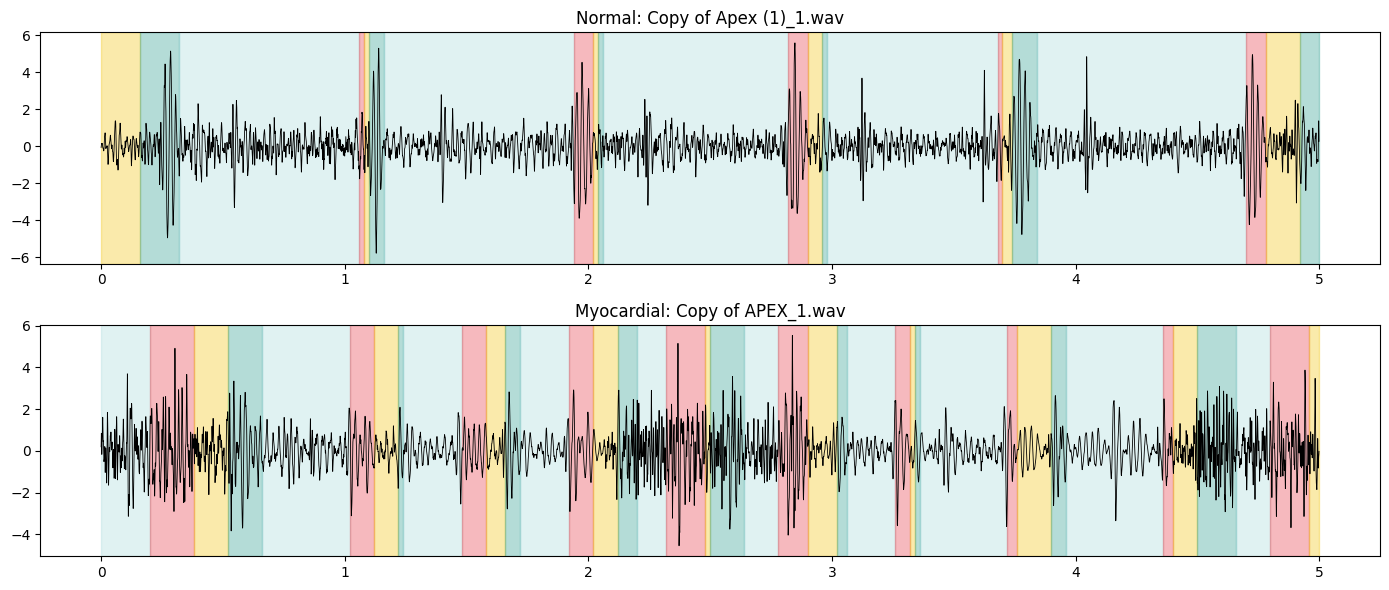

In [33]:
import matplotlib.pyplot as plt

sample_rows = manifest_run.groupby('label').first().reset_index()
fig, axes = plt.subplots(len(sample_rows), 1, figsize=(14, 3 * len(sample_rows)))
axes = [axes] if len(sample_rows) == 1 else axes
colors = {'S1': '#e63946', 'Systole': '#f1c40f', 'S2': '#2a9d8f', 'Diastole': '#a8dadc'}

for ax, row in zip(axes, sample_rows.itertuples()):
    y, sr = librosa.load(row.filepath, sr=NATIVE_SR)
    yz = zscore_normalize(bandpass_filter(y, sr))
    raw = hsmm_segment_pcg(yz, sr)
    t = np.arange(len(yz)) / sr
    ax.plot(t, yz, color='black', linewidth=0.6)
    for name, s, e in raw:
        ax.axvspan(s / sr, e / sr, color=colors[name], alpha=0.35)
    ax.set_title(f"{CLASSES[row.label]}: {pathlib.Path(row.filepath).name}")
plt.tight_layout()
plt.show()

## Hyperparameter Tune

In [ ]:
'''
N_TUNING_TRIALS = 3 if QUICK_TEST else 15
TUNING_SEARCH_SEED = 0

best_hp_per_model, best_model_kwargs_per_model, trial_log_df, cv_manifest = tune_all_models(
    manifest_pp, model_names=list(MODEL_CONFIGS.keys()), n_trials=N_TUNING_TRIALS,
    search_seed=TUNING_SEARCH_SEED, holdout_frac=0.2, tuning_val_frac=0.3,
    device=DEVICE if 'DEVICE' in dir() else ('cuda' if torch.cuda.is_available() else 'cpu'),
    tune_max_epochs=(3 if QUICK_TEST else 25), tune_patience=(2 if QUICK_TEST else 6))

trial_log_df.to_csv('hyperparameter_search_log.csv', index=False)
print(f"\nSaved every trial's config + val AUROC to hyperparameter_search_log.csv "
      f"({len(trial_log_df)} rows) -- worth keeping/reporting as evidence the search "
      f"wasn't cherry-picked after the fact.")
'''

In [35]:
import os
import pandas as pd

LOAD_FROM_EXISTING = True
CSV_PATH = "E:\notebook\hyperparameter_search_log.csv"

if LOAD_FROM_EXISTING and os.path.exists(CSV_PATH):
    print(f"Loading existing hyperparameter search log from: {CSV_PATH}")
    trial_log_df = pd.read_csv(CSV_PATH)

    TUNING_SEARCH_SEED = 0
    _, cv_manifest = split_tuning_holdout(manifest_pp, holdout_frac=0.2, seed=TUNING_SEARCH_SEED)

    best_hp_per_model = {}
    best_model_kwargs_per_model = {}

    for name in trial_log_df['model'].unique():
        model_trials = trial_log_df[trial_log_df['model'] == name]
        best_idx = model_trials['val_auroc'].idxmax()
        best_row = model_trials.loc[best_idx]

        best_hp_per_model[name] = dict(
            HYPERPARAMS, **RECOMMENDED_DEFAULTS,
            lr=float(best_row['lr']),
            weight_decay=float(best_row['weight_decay']),
            batch_size=int(best_row['batch_size'])
        )
        best_model_kwargs_per_model[name] = dict(
            dropout=float(best_row['dropout']),
            attn_dim=int(best_row['attn_dim'])
        )
        print(f"Loaded {name}: val_AUROC={best_row['val_auroc']:.4f}")

else:
    print("Existing CSV not found or LOAD_FROM_EXISTING is False. Running tuning search...")

Existing CSV not found or LOAD_FROM_EXISTING is False. Running tuning search...
Tuning holdout: 28 patients (20 tune-train / 8 tune-val)
Remaining for the actual 5-fold CV: 112 patients

Global-CNN         best tuning-val AUROC=0.8750  lr=2.37e-04  wd=7.33e-05  dropout=0.20  batch=8  attn_dim=32
Fixed-MBCNN        best tuning-val AUROC=0.8750  lr=1.72e-03  wd=2.24e-05  dropout=0.36  batch=4  attn_dim=32
Phase-MBCNN        best tuning-val AUROC=0.8750  lr=1.39e-03  wd=6.68e-05  dropout=0.33  batch=4  attn_dim=16
Phase-AttNet       best tuning-val AUROC=0.8750  lr=1.39e-03  wd=6.68e-05  dropout=0.33  batch=4  attn_dim=16
Location-AttNet    best tuning-val AUROC=0.8750  lr=1.39e-03  wd=6.68e-05  dropout=0.33  batch=4  attn_dim=16
PLAF-Net           best tuning-val AUROC=0.8750  lr=1.72e-03  wd=2.24e-05  dropout=0.36  batch=4  attn_dim=32

Saved every trial's config + val AUROC to hyperparameter_search_log.csv


## Quick Check

In [36]:
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
quick_hp_per_model = {name: dict(hp, max_epochs=1, early_stop_patience=3)
                       for name, hp in best_hp_per_model.items()}

print('--- Table 7 (patient leakage) ---')
table7 = run_experiment2_leakage(cv_manifest, seeds=(21,), n_folds=2, device=DEVICE,
                                  hp=quick_hp_per_model['PLAF-Net'],
                                  model_kwargs=best_model_kwargs_per_model['PLAF-Net'])
print(table7.to_string(index=False))

--- Table 7 (patient leakage) ---
                  Protokol Overlap_pasien      Macro_F1         AUROC
Random segment-level 80:20 111/112 pasien 0.335 ± 0.000 0.668 ± 0.000
Patient-independent 2-fold      Tidak ada 0.333 ± 0.000 0.597 ± 0.070


In [37]:
print('--- Tables 8, 9, 12 (controlled comparison + ablation) ---')
long_df, table8, table9, table12, oof_by_model = run_experiments_3_4(
    cv_manifest, n_folds=2, seeds=(21,), device=DEVICE,
    hp_per_model=quick_hp_per_model, model_kwargs_per_model=best_model_kwargs_per_model)
print(table8.to_string(index=False))
print()
print(table12.to_string(index=False))

--- Tables 8, 9, 12 (controlled comparison + ablation) ---
          Model      Macro_F1  Sensitivitas  Spesifisitas         AUROC
     Global-CNN 0.333 ± 0.000 1.000 ± 0.000 0.000 ± 0.000 0.816 ± 0.090
    Fixed-MBCNN 0.533 ± 0.282 0.857 ± 0.202 0.375 ± 0.530 0.856 ± 0.081
    Phase-MBCNN 0.333 ± 0.000 1.000 ± 0.000 0.000 ± 0.000 0.596 ± 0.093
   Phase-AttNet 0.333 ± 0.000 1.000 ± 0.000 0.000 ± 0.000 0.621 ± 0.111
Location-AttNet 0.333 ± 0.000 1.000 ± 0.000 0.000 ± 0.000 0.609 ± 0.106
       PLAF-Net 0.333 ± 0.000 1.000 ± 0.000 0.000 ± 0.000 0.597 ± 0.099

    Konfigurasi Phase_attention Location_attention      Macro_F1         AUROC
    Phase-MBCNN           Tidak              Tidak 0.333 ± 0.000 0.596 ± 0.093
   Phase-AttNet              Ya              Tidak 0.333 ± 0.000 0.621 ± 0.111
Location-AttNet           Tidak                 Ya 0.333 ± 0.000 0.609 ± 0.106
       PLAF-Net              Ya                 Ya 0.333 ± 0.000 0.597 ± 0.099


In [38]:
print('--- Table 11 (single-channel / fusion strategies) ---')
table11 = run_experiment5_phase_location(cv_manifest, n_folds=2, seeds=(21,), device=DEVICE,
                                          hp=quick_hp_per_model['PLAF-Net'],
                                          model_kwargs=best_model_kwargs_per_model['PLAF-Net'])
print(table11.to_string(index=False))

print()
print('--- Table 13 (attention weight stability) ---')
table13 = run_experiment6_attention_stability(cv_manifest, n_folds=2, seeds=(21,), device=DEVICE,
                                               hp=quick_hp_per_model['PLAF-Net'],
                                               model_kwargs=best_model_kwargs_per_model['PLAF-Net'])
print(table13.to_string(index=False))

--- Table 11 (single-channel / fusion strategies) ---
                            Konfigurasi      Macro_F1         AUROC
Kombinasi tunggal terbaik: sistol--Apex 0.329 ± 0.004 0.376 ± 0.057
                   Seluruh fase di Apex 0.344 ± 0.019 0.404 ± 0.074
                   Seluruh fase di LLSB 0.386 ± 0.053 0.422 ± 0.017
                  Sistol seluruh lokasi 0.333 ± 0.000 0.554 ± 0.076

--- Table 13 (attention weight stability) ---
Tingkat    Kanal Bobot_rata_rata SD_antar_fold
   Fase       S1            0.25          0.00
   Fase  Systole            0.25          0.00
   Fase       S2            0.25          0.00
   Fase Diastole            0.26          0.00
 Lokasi     Apex            0.25          0.00
 Lokasi     RUSB            0.25          0.00
 Lokasi     LUSB            0.25          0.00
 Lokasi     LLSB            0.25          0.00


In [39]:
print('--- Tables 14-15 (statistics) ---')
table14, table15 = run_planned_comparisons(oof_by_model)
print(table15.to_string(index=False))

print()
print('--- Table 16 (compute profiling) ---')
_plafnet_kwargs = best_model_kwargs_per_model['PLAF-Net']
table16 = build_table16(PLAFNet(phase_mode='phase', phase_fusion='attention',
                                 location_fusion='attention', **_plafnet_kwargs))
print(table16.to_string(index=False))

--- Tables 14-15 (statistics) ---
Kode                   Perbandingan  delta_macro_f1     ci_lo     ci_hi  p_bootstrap  delta_auroc     p_delong  p_holm_f1  p_holm_auroc
  C1         PLAF-Net vs Global-CNN        0.000000  0.000000  0.000000        1.000    -0.112564 8.395957e-07        1.0  3.358383e-06
  C2        PLAF-Net vs Fixed-MBCNN       -0.259049 -0.348974 -0.164316        0.965    -0.129464 4.229444e-08        1.0  2.114722e-07
  C3        PLAF-Net vs Phase-MBCNN        0.000000  0.000000  0.000000        1.000    -0.039222 8.714670e-02        1.0  2.614401e-01
  C4    Phase-AttNet vs Phase-MBCNN        0.000000  0.000000  0.000000        1.000    -0.027423 2.509741e-01        1.0  2.614401e-01
  C5 Location-AttNet vs Phase-MBCNN        0.000000  0.000000  0.000000        1.000    -0.036671 1.059498e-01        1.0  2.614401e-01

--- Table 16 (compute profiling) ---
                    Ukuran komputasi                                                    Nilai
        Parameter 

## Manual Table

In [43]:
def build_manual_verification_table(oof_by_model, model_names=None):
    model_names = model_names or list(oof_by_model.keys())
    base = None
    for name in model_names:
        df = oof_by_model[name][['patient_id', 'label', 'prob', 'threshold']].copy()
        df = df.rename(columns={'prob': f'prob_{name}', 'threshold': f'threshold_{name}'})
        if base is None:
            base = df
        else:
            base = base.merge(df.drop(columns=['label']), on='patient_id', how='inner')
    return base

In [45]:
def build_oof_stat_table(oof_by_model, planned_comparisons=PLANNED_COMPARISONS):
    dfs = []
    for name, df in oof_by_model.items():
        d = df.set_index('patient_id')[['label', 'prob']].rename(columns={'prob': f'prob_{name}'})
        dfs.append(d)

    wide = dfs[0][['label']].copy()
    for d in dfs:
        wide = wide.join(d.drop(columns='label'), how='inner')
    for d in dfs[1:]:
        wide = wide.join(d[['label']].rename(columns={'label': '_chk'}), how='inner')
        assert (wide['label'] == wide['_chk']).all(), "label mismatch across models for same patient!"
        wide = wide.drop(columns='_chk')

    wide = wide.reset_index()

    for code, model_a, model_b in planned_comparisons:
        ca, cb = f'prob_{model_a}', f'prob_{model_b}'
        if ca in wide.columns and cb in wide.columns:
            wide[f'{code}_delta_prob'] = wide[ca] - wide[cb]

    return wide

## Real Data

In [40]:
REAL_SEEDS = (21, 42, 84)
N_FOLDS = 5

In [42]:
print('--- Tables 8, 9, 12 (controlled comparison + ablation) ---')
long_df, table8, table9, table12, oof_by_model = run_experiments_3_4(
    cv_manifest, model_names=['Global-CNN'], n_folds=N_FOLDS, seeds=REAL_SEEDS, device=DEVICE,
    hp_per_model=best_hp_per_model, model_kwargs_per_model=best_model_kwargs_per_model)
display(table8)
display(table9)
display(table12)

--- Tables 8, 9, 12 (controlled comparison + ablation) ---


,Model,Macro_F1,Sensitivitas,Spesifisitas,AUROC
0,Global-CNN,0.777 ± 0.115,0.923 ± 0.082,0.668 ± 0.148,0.901 ± 0.087


model,Global-CNN
fold,
0,0.853 ± 0.024
1,0.747 ± 0.18
2,0.732 ± 0.346
3,0.627 ± 0.005
4,0.923 ± 0.054


""


In [47]:
stat_table = build_oof_stat_table(oof_by_model)
stat_table.to_csv('oof_stat_table.csv', index=False)
display(stat_table)

,patient_id,label,prob_Global-CNN
0,Myocardial_Abdul_Qadir,1,0.698068
1,Myocardial_Agus_Supriadi,1,0.576118
2,Myocardial_Ating_Cartim,1,0.636710
3,Myocardial_Budi_Agustian,1,0.673519
4,Myocardial_Didi_Hermawan,1,0.666381
...,...,...,...
107,Normal_45,0,0.245388
108,Normal_47,0,0.772426
109,Normal_57,0,0.174935
110,Normal_61,0,0.503467


In [48]:
print('--- Tables 8, 9, 12 (controlled comparison + ablation) ---')
long_df, table8, table9, table12, oof_by_model = run_experiments_3_4(
    cv_manifest, model_names=['Fixed-MBCNN'], n_folds=N_FOLDS, seeds=REAL_SEEDS, device=DEVICE,
    hp_per_model=best_hp_per_model, model_kwargs_per_model=best_model_kwargs_per_model)
display(table8)
display(table9)
display(table12)

--- Tables 8, 9, 12 (controlled comparison + ablation) ---


,Model,Macro_F1,Sensitivitas,Spesifisitas,AUROC
0,Fixed-MBCNN,0.741 ± 0.122,0.845 ± 0.163,0.694 ± 0.231,0.913 ± 0.051


model,Fixed-MBCNN
fold,
0,0.854 ± 0.051
1,0.615 ± 0.253
2,0.878 ± 0.027
3,0.723 ± 0.125
4,0.633 ± 0.271


""


In [49]:
stat_table = build_oof_stat_table(oof_by_model)
stat_table.to_csv('fixedmbcnn_stat_table.csv', index=False)
display(stat_table)

,patient_id,label,prob_Fixed-MBCNN
0,Myocardial_Abdul_Qadir,1,0.733462
1,Myocardial_Agus_Supriadi,1,0.494030
2,Myocardial_Ating_Cartim,1,0.679046
3,Myocardial_Budi_Agustian,1,0.732571
4,Myocardial_Didi_Hermawan,1,0.688962
...,...,...,...
107,Normal_45,0,0.686021
108,Normal_47,0,0.914904
109,Normal_57,0,0.335967
110,Normal_61,0,0.866358


In [50]:
print('--- Tables 8, 9, 12 (controlled comparison + ablation) ---')
long_df, table8, table9, table12, oof_by_model = run_experiments_3_4(
    cv_manifest, model_names=['Phase-MBCNN'], n_folds=N_FOLDS, seeds=REAL_SEEDS, device=DEVICE,
    hp_per_model=best_hp_per_model, model_kwargs_per_model=best_model_kwargs_per_model)
display(table8)
display(table9)
display(table12)

--- Tables 8, 9, 12 (controlled comparison + ablation) ---


,Model,Macro_F1,Sensitivitas,Spesifisitas,AUROC
0,Phase-MBCNN,0.695 ± 0.172,0.693 ± 0.148,0.793 ± 0.138,0.862 ± 0.121


model,Phase-MBCNN
fold,
0,0.884 ± 0.025
1,0.615 ± 0.237
2,0.717 ± 0.332
3,0.447 ± 0.198
4,0.814 ± 0.083


,Konfigurasi,Phase_attention,Location_attention,Macro_F1,AUROC
0,Phase-MBCNN,Tidak,Tidak,0.695 ± 0.172,0.862 ± 0.121


In [51]:
stat_table = build_oof_stat_table(oof_by_model)
stat_table.to_csv('phasembcnn_stat_table.csv', index=False)
display(stat_table)

,patient_id,label,prob_Phase-MBCNN
0,Myocardial_Abdul_Qadir,1,0.934585
1,Myocardial_Agus_Supriadi,1,0.581678
2,Myocardial_Ating_Cartim,1,0.661371
3,Myocardial_Budi_Agustian,1,0.762605
4,Myocardial_Didi_Hermawan,1,0.814583
...,...,...,...
107,Normal_45,0,0.308289
108,Normal_47,0,0.667042
109,Normal_57,0,0.340597
110,Normal_61,0,0.441052


In [52]:
print('--- Tables 8, 9, 12 (controlled comparison + ablation) ---')
long_df, table8, table9, table12, oof_by_model = run_experiments_3_4(
    cv_manifest, model_names=['Phase-AttNet'], n_folds=N_FOLDS, seeds=REAL_SEEDS, device=DEVICE,
    hp_per_model=best_hp_per_model, model_kwargs_per_model=best_model_kwargs_per_model)
display(table8)
display(table9)
display(table12)

--- Tables 8, 9, 12 (controlled comparison + ablation) ---


,Model,Macro_F1,Sensitivitas,Spesifisitas,AUROC
0,Phase-AttNet,0.726 ± 0.200,0.808 ± 0.234,0.721 ± 0.284,0.864 ± 0.130


model,Phase-AttNet
fold,
0,0.913 ± 0.0
1,0.778 ± 0.044
2,0.908 ± 0.047
3,0.539 ± 0.181
4,0.494 ± 0.279


,Konfigurasi,Phase_attention,Location_attention,Macro_F1,AUROC
0,Phase-AttNet,Ya,Tidak,0.726 ± 0.200,0.864 ± 0.130


In [53]:
stat_table = build_oof_stat_table(oof_by_model)
stat_table.to_csv('phaseattnet_stat_table.csv', index=False)
display(stat_table)

,patient_id,label,prob_Phase-AttNet
0,Myocardial_Abdul_Qadir,1,0.966969
1,Myocardial_Agus_Supriadi,1,0.588144
2,Myocardial_Ating_Cartim,1,0.687747
3,Myocardial_Budi_Agustian,1,0.855509
4,Myocardial_Didi_Hermawan,1,0.915914
...,...,...,...
107,Normal_45,0,0.368173
108,Normal_47,0,0.595885
109,Normal_57,0,0.473444
110,Normal_61,0,0.489169


In [54]:
print('--- Tables 8, 9, 12 (controlled comparison + ablation) ---')
long_df, table8, table9, table12, oof_by_model = run_experiments_3_4(
    cv_manifest, model_names=['Location-AttNet'], n_folds=N_FOLDS, seeds=REAL_SEEDS, device=DEVICE,
    hp_per_model=best_hp_per_model, model_kwargs_per_model=best_model_kwargs_per_model)
display(table8)
display(table9)
display(table12)

--- Tables 8, 9, 12 (controlled comparison + ablation) ---


,Model,Macro_F1,Sensitivitas,Spesifisitas,AUROC
0,Location-AttNet,0.693 ± 0.239,0.746 ± 0.257,0.728 ± 0.233,0.850 ± 0.131


model,Location-AttNet
fold,
0,0.882 ± 0.025
1,0.735 ± 0.154
2,0.939 ± 0.053
3,0.544 ± 0.185
4,0.365 ± 0.054


,Konfigurasi,Phase_attention,Location_attention,Macro_F1,AUROC
0,Location-AttNet,Tidak,Ya,0.693 ± 0.239,0.850 ± 0.131


In [55]:
stat_table = build_oof_stat_table(oof_by_model)
stat_table.to_csv('locattnet_stat_table.csv', index=False)
display(stat_table)

,patient_id,label,prob_Location-AttNet
0,Myocardial_Abdul_Qadir,1,0.880168
1,Myocardial_Agus_Supriadi,1,0.719561
2,Myocardial_Ating_Cartim,1,0.752314
3,Myocardial_Budi_Agustian,1,0.796218
4,Myocardial_Didi_Hermawan,1,0.807966
...,...,...,...
107,Normal_45,0,0.531141
108,Normal_47,0,0.647561
109,Normal_57,0,0.642494
110,Normal_61,0,0.644484


## PLAFNet

In [61]:
print('--- Tables 8, 9, 12 (controlled comparison + ablation) ---')
long_df, table8, table9, table12, oof_by_model = run_experiments_3_4(
    cv_manifest, model_names=['PLAF-Net'], n_folds=N_FOLDS, seeds=REAL_SEEDS, device=DEVICE,
    hp_per_model=best_hp_per_model, model_kwargs_per_model=best_model_kwargs_per_model)
display(table8)
display(table9)
display(table12)

--- Tables 8, 9, 12 (controlled comparison + ablation) ---


,Model,Macro_F1,Sensitivitas,Spesifisitas,AUROC
0,PLAF-Net,0.802 ± 0.120,0.836 ± 0.163,0.773 ± 0.170,0.933 ± 0.049


model,PLAF-Net
fold,
0,0.865
1,0.646
2,0.954
3,0.725
4,0.817


,Konfigurasi,Phase_attention,Location_attention,Macro_F1,AUROC
0,PLAF-Net,Ya,Ya,0.802 ± 0.120,0.933 ± 0.049


In [62]:
stat_table = build_oof_stat_table(oof_by_model)
stat_table.to_csv('plafnet_stat_table.csv', index=False)
display(stat_table)

,patient_id,label,prob_PLAF-Net
0,Myocardial_Abdul_Qadir,1.0,0.932922
1,Myocardial_Agus_Supriadi,1.0,0.832553
2,Myocardial_Ating_Cartim,1.0,0.844439
3,Myocardial_Budi_Agustian,1.0,0.853608
4,Myocardial_Didi_Hermawan,1.0,0.891663
...,...,...,...
107,Normal_45,0.0,0.401780
108,Normal_47,0.0,0.652278
109,Normal_57,0.0,0.574945
110,Normal_61,0.0,0.544695


## All

In [63]:
print('--- Table 16 (compute profiling) ---')
_plafnet_kwargs = best_model_kwargs_per_model['PLAF-Net']
table16 = build_table16(PLAFNet(phase_mode='phase', phase_fusion='attention',
                                 location_fusion='attention', **_plafnet_kwargs))
print(table16.to_string(index=False))

--- Table 16 (compute profiling) ---
                    Ukuran komputasi                                                    Nilai
        Parameter yang dapat dilatih                                                  109,825
               Ukuran parameter FP32                                                  0.42 MB
          Parameter dua modul atensi                                                    4,224
           Proporsi parameter atensi                                                     3.8%
                     MACs per pasien                                               1.08 GMACs
                    FLOPs per pasien                                              2.16 GFLOPs
Memori GPU puncak, inferensi batch 1                                                 45.10 GB
Memori GPU puncak, pelatihan batch 8                                               1027.66 GB
              Latensi CPU per pasien                                            20.3 ± 1.2 ms
              Latensi G

In [ ]:
# All Experiments
table5 = summarize_table5_table6(qc_log)
table7 = run_experiment2_leakage(cv_manifest, seeds=REAL_SEEDS, n_folds=N_FOLDS, device=DEVICE,
                                  hp=best_hp_per_model['PLAF-Net'],
                                  model_kwargs=best_model_kwargs_per_model['PLAF-Net'])
long_df, table8, table9, table12, oof_by_model = run_experiments_3_4(
    cv_manifest, n_folds=N_FOLDS, seeds=REAL_SEEDS, device=DEVICE,
    hp_per_model=best_hp_per_model, model_kwargs_per_model=best_model_kwargs_per_model)
table11 = run_experiment5_phase_location(cv_manifest, n_folds=N_FOLDS, seeds=REAL_SEEDS, device=DEVICE,
                                          hp=best_hp_per_model['PLAF-Net'],
                                          model_kwargs=best_model_kwargs_per_model['PLAF-Net'])
table13 = run_experiment6_attention_stability(cv_manifest, n_folds=N_FOLDS, seeds=REAL_SEEDS, device=DEVICE,
                                               hp=best_hp_per_model['PLAF-Net'],
                                               model_kwargs=best_model_kwargs_per_model['PLAF-Net'])
table14, table15 = run_planned_comparisons(oof_by_model)
_plafnet_kwargs = best_model_kwargs_per_model['PLAF-Net']
table16 = build_table16(PLAFNet(phase_mode='phase', phase_fusion='attention',
                                 location_fusion='attention', **_plafnet_kwargs))

for name, df in [('table5', table5), ('table7', table7), ('table8', table8), ('table9', table9),
                  ('table11', table11), ('table12', table12), ('table13', table13),
                  ('table14', table14), ('table15', table15), ('table16', table16)]:
    df.to_csv(f'{name}.csv', index=(name != 'table9'))
print("Saved all tables to the current directory.")